# USES CALC V2 and MC V4 AND NEW REBOUND

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from src.simulations.Rebound_v4 import OrbitalSimulation
from numpy.random import SeedSequence, Generator, PCG64
import src.utils.calculations_v3 as calc
import multiprocessing
import datetime
from numpy.random import SeedSequence, Generator, PCG64
import src.simulations.MonteCarlo_impsamp_v4 as MCi
import src.configurations.Configuration as conf
import src.analysis.Analysis_v2 as anl
import src.plotting.Plotting_v2 as pl
import src.utils.misc as misc 
import src.utils.plotting_utils as pu

import datetime as dt
import os
import pandas as pd
import seaborn as sns
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
H = cosmo.H(0).to(u.yr**-1).value  # Hubble constant in 1/yr
print(f"Hubble time: {1/H:.2e} yr")
# Simulation Runs
mPBH_grid = np.linspace(1.5e-7, 1e-4, 10) * const.M_sun.value  # from 1e-10 to 1 solar mass
mPBH_grid = np.logspace(np.log10(1e-8), np.log10(1e-1), 8) * const.M_sun.value  # from 1e-10 to 1 solar mass
print(mPBH_grid)
run_dict1, rundict2, rundict3, run_dict4, run_dict5 = {}, {}, {}, {}, {}
n = 0
size = 200
for j in [run_dict1, rundict2, rundict3, run_dict4, run_dict5][:1]:
    for i, mPBH in enumerate(mPBH_grid):
        seed = i + n # Just a way to get different seeds
        name = f"BetaPictoris_s{seed}_Mpbh{mPBH/const.M_sun.value:.0e}_M4R4C3"
        configuration = conf.Configuration(name=name, seed=seed, importance_sampling=True, config_file='src/configurations/BetaPictoris.yaml')
        configuration.set_system_param('mC', mPBH)  # Mass of light PBH
        configuration.set_simulation_param('sample_size', size)  # Mass of light PBH
        configuration.set_simulation_param('max_trials', 1000000000)  # Mass of light PBH
        max_v_default = configuration.get_simulation_param(all=True)['v_inf_grid'][-1]
        configuration.set_simulation_param('max_v', max_v_default*0.75) # From Dehnen 2022, for circular Jupiter 31.6 km/s
        configuration.print_configuration()
        j[name] = {'name': name, 'seed': seed, 'configuration': configuration}
        print(f"Prepared configuration for mPBH = {mPBH / const.M_sun.value} solar masses.\n")
    n += 10

Using REPO_ROOT: /data/a.saricaoglu/repo/captus
Hubble time: 1.40e+10 yr
[1.98840987e+22 1.98840987e+23 1.98840987e+24 1.98840987e+25
 1.98840987e+26 1.98840987e+27 1.98840987e+28 1.98840987e+29]
Updated system parameter 'mC' to 1.988409870698051e+22 and recalculated rC.
Updated v_inf_grid_params 'max_v' to 28810.81207883589 and regenerated v_inf_grid.
System Parameters:
  mA: 3.479717273721589e+30
  mB: 2.4675619765368657e+28
  mC: 1.988409870698051e+22
  aB: 1495978707000.0
  rB: 100088800.0
  rA: 1182690000.0
  vB: 12459.830528263383
  eB: 0.0489
  iB: 0.02275909344600606
  epsilon: 0.1
  name: BetaPictoris_s0_Mpbh1e-08_M4R4C3
  seed_base: 0
  rC: 2.9532500761002496e-05

Simulation Parameters:
  trials: 10000000
  max_trials: 1000000000
  max_execution_time: 3600
  sample_size: 200
  max_e: 1.0
  vDM: 220000.0
  v_inf_grid_params: {'min_v': 1000, 'max_v': np.float64(28810.81207883589), 'n_v': 10}
  importance_sampling: True
  v_inf_grid: [ 1000.          4090.09023098  7180.18046196

## Simulation Runs

In [21]:

def mc_worker(pars):
    conf, child_ss, v_inf = pars
    rng = Generator(PCG64(child_ss)) # independent per worker
    simulation = MCi.MonteCarloSimulation(conf, rng)
    return simulation.run_monte_carlo_simulation(v_inf)

if __name__ == "__main__":
    

    for run_dict in [run_dict1, rundict2, rundict3, run_dict4, run_dict5][:1]:  # Only run the first configuration for now
        start_time = datetime.datetime.now()
        all_pars = []
        print(f"Run: {list(run_dict.keys())[0]} to {list(run_dict.keys())[-1]}")   
        for run in run_dict.values():
            print(f"Preparing simulation: {run['name']}")
            configuration_ = run['configuration']
            seed_ = run['seed']
            v_inf_grid_ = configuration_.get_simulation_param('v_inf_grid')
            base_ss = SeedSequence(seed_)
            print(f'  {len(v_inf_grid_)} v_inf values: {v_inf_grid_[0]:.1f} to {v_inf_grid_[-1]:.1f} m/s')
            child_sss = base_ss.spawn(len(v_inf_grid_))
            pars = [(configuration_, child_sss[i], v_inf_grid_[i]) for i in range(len(v_inf_grid_))]
            all_pars.extend(pars)
    
        num_cores = 50
        print(f'\n{"="*60}')
        print(f'Total simulations to run: {len(all_pars)}')
        print(f'Configurations: {len(run_dict)}')
        print(f'CPU cores: {num_cores}')
        print(f'{"="*60}\n')
        
        with multiprocessing.Pool(processes=num_cores) as pool:
            results = pool.map(mc_worker, all_pars)
        
        elapsed_time = datetime.datetime.now() - start_time
        print(f'\n{"="*60}')
        print(f'✓ All simulations complete!')
        print(f'Total time: {elapsed_time} ({elapsed_time.total_seconds()/60:.2f} minutes)')
        print(f'Completed {len(all_pars)} simulations across {len(run_dict)} configurations')
        print(f'{"="*60}')

Run: BetaPictoris_s0_Mpbh1e-08_M4R4C3 to BetaPictoris_s6_Mpbh1e-02_M4R4C3
Preparing simulation: BetaPictoris_s0_Mpbh1e-08_M4R4C3
  10 v_inf values: 1000.0 to 28810.8 m/s
Preparing simulation: BetaPictoris_s1_Mpbh1e-07_M4R4C3
  10 v_inf values: 1000.0 to 28810.8 m/s
Preparing simulation: BetaPictoris_s2_Mpbh1e-06_M4R4C3
  10 v_inf values: 1000.0 to 28810.8 m/s
Preparing simulation: BetaPictoris_s3_Mpbh1e-05_M4R4C3
  10 v_inf values: 1000.0 to 28810.8 m/s
Preparing simulation: BetaPictoris_s4_Mpbh1e-04_M4R4C3
  10 v_inf values: 1000.0 to 28810.8 m/s
Preparing simulation: BetaPictoris_s5_Mpbh1e-03_M4R4C3
  10 v_inf values: 1000.0 to 28810.8 m/s
Preparing simulation: BetaPictoris_s6_Mpbh1e-02_M4R4C3
  10 v_inf values: 1000.0 to 28810.8 m/s

Total simulations to run: 70
Configurations: 7
CPU cores: 50



for v_inf=28.81081207883589 km/s and mC 1e-07 M_sun MC capture cross-section: 2.6284171452146898e+22for v_inf=28.81081207883589 km/s and mC 1e-06 M_sun MC capture cross-section: m^2 
2.699040653755829e+22for v_inf=28.81081207883589 km/s and mC 1e-07 M_sun MC capture cross-section (dσ avg):  m^20.0005482396514204738 AU2
 for v_inf=28.81081207883589 km/s and mC 1e-06 M_sun MC capture cross-section (dσ avg):au^2 
0.0005880323650024346 AU2 Number of captured orbits: 200, e condition met: 258, out of 268 samples.
au^2
Number of captured orbits: 200, e condition met: 254, out of 261 samples.
Results saved for v_inf=28.81081207883589 km/s with N=261 trials.
Results saved for v_inf=28.81081207883589 km/s with N=268 trials.
for v_inf=25.720721847854126 km/s and mC 1e-06 M_sun MC capture cross-section: 2.784385812767871e+22 m^2
for v_inf=25.720721847854126 km/s and mC 1e-06 M_sun MC capture cross-section (dσ avg): 0.001273329172774038 AU2 au^2
Number of captured orbits: 200, e condition met: 242

In [3]:
for run_dict in [run_dict1, rundict2, rundict3, run_dict4, run_dict5][:1]:    
    for run in run_dict.values():

        configuration = run['configuration']
        name = run['name']
        analysis = anl.Analysis(name=configuration.name, configuration=configuration)
        mc = analysis.get_mc_results()
        sampled_mc = analysis.get_sampled_mc_results()
        # catalog = analysis.get_combined_dictionary()
        run_dict[name]['sampled_mc'] = sampled_mc
        run_dict[name]['mc'] = mc
        # run_dict[name]['catalog'] = catalog
        run_dict[name]['analysis'] = analysis
        print(f"Loaded results for {name}.")
    # Debug: Check MC data structure and read inclinations

        

    

Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s0_Mpbh1e-08_M4R4C3/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s0_Mpbh1e-08_M4R4C3/Rebound_Simulation_Results/
Loaded results for BetaPictoris_s0_Mpbh1e-08_M4R4C3.
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s1_Mpbh1e-07_M4R4C3/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s1_Mpbh1e-07_M4R4C3/Rebound_Simulation_Results/
Loaded results for BetaPictoris_s1_Mpbh1e-07_M4R4C3.
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s2_Mpbh1e-06_M4R4C3/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s2_Mpbh1e-06_M4R4C3/Rebound_Simulation_Results/
Loaded results for BetaPictoris_s2_Mpbh1e-06_M4R4C3.
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s3_Mpbh1e-05_M4R4C3/Monte_Carlo_Results/


In [ ]:
import time
def check_result_exists_v2(configuration, v_inf_kms, i, seed):
    """Check if a result file already exists"""
    v_str = f"{v_inf_kms:.0f}"
    save_dir = configuration.get_save_dir_rebound()
    dir_npz = os.path.join(save_dir, f"v{v_str}")
    out_npz = os.path.join(dir_npz, f"sim_{i}_{seed}.npz")
    return os.path.isfile(out_npz)
    # return False
    
def rebound_worker_v2(pars):
    configuration, child_ss, i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B= pars
    rng = Generator(PCG64(child_ss))
    simulation = OrbitalSimulation(configuration=configuration, rng=rng)
    return simulation.run_orbital_integration(i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B)
def timed_rebound_worker_v2(pars):
    t0 = time.perf_counter()
    try:
        out = rebound_worker_v2(pars)
        ok, err = True, None
    except Exception as e:
        out = None
        ok, err = False, repr(e)
    dt_s = time.perf_counter() - t0

    # Pars layout: (configuration, child_ss, i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B)
    configuration, _child_ss, i, v_inf, *_rest = pars
    return {
        "conf_name": getattr(configuration, "name", "unknown"),
        "seed": getattr(configuration, "seed", None),
        "i": int(i),
        "v_inf": float(v_inf),
        "elapsed_s": float(dt_s),
        "ok": ok,
        "err": err,
        # keep the original output if you want to inspect it later
        "out": out,
    }

if __name__ == "__main__":
    overall_start = datetime.datetime.now()
    num_cores = 40
    verbose_per_system = True          # <- set False if too spammy
    progress_every = 100   

    for run_dict in [run_dict1, rundict2, rundict3, run_dict4, run_dict5][:1]:
    # for run_dict in [run_dict6][:1]:  # Loop over each run_dict (configuration set)
    # Build parameter list for ALL runs together
        all_pars = []
        run_info = []  # Track which parameters belong to which run
        
        for run in run_dict.values():
            print(f"Preparing {run['name']}...")
            conf_ = run['configuration']
            seed_ = run['seed']
            sampled_mc_ = run['sampled_mc']
            
            # Generate seeds for this run
            base_ss = SeedSequence(seed_)
            total_possible = np.sum([len(vdata['idx']) for vdata in sampled_mc_.values()])
            all_child_sss = base_ss.spawn(int(total_possible))
            
            # Build parameters for this run
            run_pars = []
            global_idx = 0
            skipped = 0
            
            for v_key in sorted(sampled_mc_.keys(), key=lambda k: int(k[1:]) if isinstance(k, str) and k.startswith("v") and k[1:].isdigit() else str(k)):
                vdata = sampled_mc_[v_key]
                v_inf = vdata['v_inf']
                v_inf_kms = v_inf / 1e3
                lambda1 = vdata['cap_lambda']
                beta = vdata['cap_beta']
                b = vdata['cap_b']
                phi = vdata['cap_phi']
                pos_C = vdata['cap_C_pos']
                v_C = vdata['cap_C_v2']
                pos_B = vdata['cap_B_pos']
                v_B = vdata['cap_B_v']


                for i in sorted(vdata['idx']):
                    if not check_result_exists_v2(conf_, v_inf_kms, i, seed_):
                        run_pars.append((
                            conf_,
                            all_child_sss[global_idx],
                            i, v_inf, lambda1[i], beta[i], phi[i], b[i],
                            pos_C[i], v_C[i], pos_B[i], v_B[i]
                        ))
                    else:
                        skipped += 1
                    
                    global_idx += 1
            
            all_pars.extend(run_pars)
            run_info.append({
                'name': run['name'],
                'n_sims': len(run_pars),
                'skipped': skipped
            })
            print(f"  Added {len(run_pars)} simulations (skipped {skipped})")
        
        # Run ALL simulations in one pool
        total_to_run = len(all_pars)
        print(f"\n{'='*70}")
        print(f"Running {total_to_run} total simulations across {len(run_dict)} runs")
        print(f"Using {num_cores} cores")
        print(f"{'='*70}\n")
        
        if total_to_run == 0:
            print('✓ All simulations already complete!')
            continue
        
        timings = []
        records = []

        with multiprocessing.Pool(processes=min(num_cores, total_to_run)) as pool:
            for k, rec in enumerate(pool.imap_unordered(timed_rebound_worker_v2, all_pars, chunksize=1), start=1):
                records.append(rec)
                timings.append(rec["elapsed_s"])

                if verbose_per_system:
                    v_kms = rec["v_inf"] / 1e3
                    status = "OK" if rec["ok"] else f"FAIL ({rec['err']})"
                    print(f"[{k:>6}/{total_to_run}] {rec['conf_name']} sim i={rec['i']} v={v_kms:8.3f} km/s  "
                          f"t={rec['elapsed_s']:.3f} s  {status}")

                if (k % progress_every) == 0:
                    avg = sum(timings) / len(timings)
                    print(f"--- progress: {k}/{total_to_run}  avg={avg:.3f}s  max={max(timings):.3f}s ---")

        # Summary + optional CSV
        df = pd.DataFrame.from_records(records)
        elapsed = datetime.datetime.now() - overall_start

        print(f"\n{'='*70}")
        print(f"Total wall time: {elapsed} ({elapsed.total_seconds()/60:.2f} min)")
        print(f"Per-sim (worker) time: mean={df['elapsed_s'].mean():.3f}s  "
              f"median={df['elapsed_s'].median():.3f}s  p95={df['elapsed_s'].quantile(0.95):.3f}s  "
              f"max={df['elapsed_s'].max():.3f}s")
        print("Slowest 10 sims:")
        print(df.sort_values("elapsed_s", ascending=False)[["conf_name", "seed", "i", "v_inf", "elapsed_s", "ok"]].head(10))
        print(f"{'='*70}")

        # Save timings (recommended)
        out_csv = f"rebound_timings_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        df.drop(columns=["out"], errors="ignore").to_csv(out_csv, index=False)
        print(f"Saved per-system timings to: {out_csv}")


Preparing Sun_WD_s0_Mpbh1e-08_M4R4C3...
  Added 10000 simulations (skipped 0)
Preparing Sun_WD_s1_Mpbh1e-07_M4R4C3...
  Added 10000 simulations (skipped 0)
Preparing Sun_WD_s2_Mpbh1e-06_M4R4C3...
  Added 10000 simulations (skipped 0)
Preparing Sun_WD_s3_Mpbh1e-05_M4R4C3...
  Added 10000 simulations (skipped 0)
Preparing Sun_WD_s4_Mpbh1e-04_M4R4C3...
  Added 10000 simulations (skipped 0)
Preparing Sun_WD_s5_Mpbh1e-03_M4R4C3...
  Added 10000 simulations (skipped 0)
Preparing Sun_WD_s6_Mpbh1e-02_M4R4C3...
  Added 10000 simulations (skipped 0)
Preparing Sun_WD_s7_Mpbh1e-01_M4R4C3...
  Added 10000 simulations (skipped 0)

Running 80000 total simulations across 8 runs
Using 50 cores

Error during integration: Particle C is free: E_c:  1.431357317151844, rAC: 10.946014225185737, Simulation failed for system 0, at step 50. Script continues...Error during integration: Particle C is free: E_c:  2.2862374132257024, rAC: 2.5097664511279665, Simulation failed for system 12, at step 10. Script conti

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Collision detected in system 13 at time 2.374259297836127: []Error during integration: Particle C is free: E_c:  2.873924358184433, rAC: 11.345983332727869, Simulation failed for system 35, at step 20. Script continues...Error during integration: Particle C is free: E_c:  0.533706740943849, rAC: 0.9044527610744216, Simulation failed for system 32, at step 10. Script continues...
Error during integration: Particle C is free: E_c:  3.440689006788638, rAC: 5.894661536228954, Simulation failed for system 1, at step 100. Script continues...Error during integration: Particle C is free: E_c:  7.317988322900105, rAC: 8.178687653933498, Simulation failed for system 41, at step 10. Script continues...Error during integration: Particle C is free: E_c:  65.21978505098167, rAC: 39.27893668063958, Simulation failed for system 43, at step 10. Script continues...Error during integration: Particle C is free: E_c:  4.031623640592436, rAC: 13.612182327188473, Simulation failed for system 29, at step 10. 

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Particle C is free: E_c:  20.474424166653844, rAC: 18.4178834648315, Simulation failed for system 56, at step 20. Script continues...

Error during integration: Particle C is free: E_c:  16.985033496789242, rAC: 7.133773411478421, Simulation failed for system 46, at step 50. Script continues...
Error during integration: Particle C is free: E_c:  3.6364803770256735, rAC: 2.4315316246490775, Simulation failed for system 51, at step 30. Script continues...Error during integration: Particle C is free: E_c:  1.6082174666938318, rAC: 4.790170920454724, Simulation failed for system 26, at step 170. Script continues...Error during integration: Particle C is free: E_c:  0.33025290741393754, rAC: 4.668980828976492, Simulation failed for system 6, at step 260. Script continues...Error during integration: Particle C is free: E_c:  66.92368648386169, rAC: 14.041873662297014, Simulation failed for system 27, at step 10. Script continues...


Error during integration: Partic

...

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Particle C is free: E_c:  2.359394409871719, rAC: 14.748273746303974, Simulation failed for system 757, at step 100. Script continues...
[   696/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=196 v=   1.000 km/s  t=41.722 s  OK
[   697/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=745 v=   1.000 km/s  t=0.006 s  OK
[   698/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=746 v=   1.000 km/s  t=0.005 s  OK
[   699/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=747 v=   1.000 km/s  t=0.014 s  OK
[   700/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=748 v=   1.000 km/s  t=0.004 s  OK
--- progress: 700/80000  avg=0.236s  max=41.722s ---
[   701/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=749 v=   1.000 km/s  t=0.006 s  OK
[   702/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=750 v=   1.000 km/s  t=0.012 s  OK
[   703/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=751 v=   1.000 km/s  t=0.004 s  OK
[   704/80000] Sun_WD_s0_Mpbh1e-08_M4R4C3 sim i=752 v=   1.000 km/s  t=0.013 s  OK
[   705/80000] Sun_WD_s0_Mpbh1e-08_M

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Particle C is free: E_c:  216.9778701311207, rAC: 7.26504952128651, Simulation failed for system 759, at step 10. Script continues...
Error during integration: Particle C is free: E_c:  6.2347738310428165, rAC: 7.65235992812752, Simulation failed for system 760, at step 140. Script continues...
Error during integration: Particle C is free: E_c:  17.910483377503887, rAC: 2.8512578495692766, Simulation failed for system 761, at step 230. Script continues...
Error during integration: Particle C is free: E_c:  0.037347060279618205, rAC: 8.114535657621424, Simulation failed for system 762, at step 30. Script continues...
Error during integration: Particle C is free: E_c:  0.9474477147842082, rAC: 5.405232695545754, Simulation failed for system 763, at step 10. Script continues...
Error during integration: Particle C is free: E_c:  1.9599359444645872, rAC: 9.824508890466795, Simulation failed for system 764, at step 50. Script continues...
Error during integration: 

KeyboardInterrupt: 

In [25]:
def check_result_exists_v2(configuration, v_inf_kms, i, seed):
    """Check if a result file already exists"""
    v_str = f"{v_inf_kms:.0f}"
    save_dir = configuration.get_save_dir_rebound()
    dir_npz = os.path.join(save_dir, f"v{v_str}")
    out_npz = os.path.join(dir_npz, f"sim_{i}_{seed}.npz")
    return os.path.isfile(out_npz)
    # return False
def rebound_worker_v2(pars):
    configuration, child_ss, i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B= pars
    rng = Generator(PCG64(child_ss))
    simulation = OrbitalSimulation(configuration=configuration, rng=rng)
    return simulation.run_orbital_integration(i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B)

if __name__ == "__main__":
    overall_start = datetime.datetime.now()
    num_cores = 40

    for run_dict in [run_dict1, rundict2, rundict3, run_dict4, run_dict5][:1]:

    # Build parameter list for ALL runs together
        all_pars = []
        run_info = []  # Track which parameters belong to which run
        
        for run in run_dict.values():
            print(f"Preparing {run['name']}...")
            conf_ = run['configuration']
            seed_ = run['seed']
            sampled_mc_ = run['sampled_mc']
            
            # Generate seeds for this run
            base_ss = SeedSequence(seed_)
            total_possible = np.sum([len(vdata['idx']) for vdata in sampled_mc_.values()])
            all_child_sss = base_ss.spawn(int(total_possible))
            
            # Build parameters for this run
            run_pars = []
            global_idx = 0
            skipped = 0
            
            for v_key in sorted(sampled_mc_.keys(), key=lambda k: int(k[1:]) if isinstance(k, str) and k.startswith("v") and k[1:].isdigit() else str(k)):
                vdata = sampled_mc_[v_key]
                v_inf = vdata['v_inf']
                v_inf_kms = v_inf / 1e3
                lambda1 = vdata['cap_lambda']
                beta = vdata['cap_beta']
                b = vdata['cap_b']
                phi = vdata['cap_phi']
                pos_C = vdata['cap_C_pos']
                v_C = vdata['cap_C_v2']
                pos_B = vdata['cap_B_pos']
                v_B = vdata['cap_B_v']


                for i in sorted(vdata['idx']):
                    if not check_result_exists_v2(conf_, v_inf_kms, i, seed_):
                        run_pars.append((
                            conf_,
                            all_child_sss[global_idx],
                            i, v_inf, lambda1[i], beta[i], phi[i], b[i],
                            pos_C[i], v_C[i], pos_B[i], v_B[i]
                        ))
                    else:
                        skipped += 1
                    
                    global_idx += 1
            
            all_pars.extend(run_pars)
            run_info.append({
                'name': run['name'],
                'n_sims': len(run_pars),
                'skipped': skipped
            })
            print(f"  Added {len(run_pars)} simulations (skipped {skipped})")
        
        # Run ALL simulations in one pool
        total_to_run = len(all_pars)
        print(f"\n{'='*70}")
        print(f"Running {total_to_run} total simulations across {len(run_dict)} runs")
        print(f"Using {num_cores} cores")
        print(f"{'='*70}\n")
        
        if total_to_run == 0:
            print('✓ All simulations already complete!')
        else:
            with multiprocessing.Pool(processes=min(num_cores, total_to_run)) as pool:
                results = pool.map(rebound_worker_v2, all_pars)
            
            elapsed = datetime.datetime.now() - overall_start
            print(f"\n{'='*70}")
            print(f"Total time: {elapsed} ({elapsed.total_seconds()/60:.2f} min)")
            print(f"Average: {elapsed.total_seconds()/total_to_run:.2f} sec/simulation")
            print(f"{'='*70}")
print(f"✓ ALL RUNS COMPLETE!")


Preparing BetaPictoris_s0_Mpbh1e-08_M4R4C3...
  Added 2000 simulations (skipped 0)
Preparing BetaPictoris_s1_Mpbh1e-07_M4R4C3...
  Added 2000 simulations (skipped 0)
Preparing BetaPictoris_s2_Mpbh1e-06_M4R4C3...
  Added 2000 simulations (skipped 0)
Preparing BetaPictoris_s3_Mpbh1e-05_M4R4C3...
  Added 2000 simulations (skipped 0)
Preparing BetaPictoris_s4_Mpbh1e-04_M4R4C3...
  Added 2000 simulations (skipped 0)
Preparing BetaPictoris_s5_Mpbh1e-03_M4R4C3...
  Added 2000 simulations (skipped 0)
Preparing BetaPictoris_s6_Mpbh1e-02_M4R4C3...
  Added 2000 simulations (skipped 0)

Running 14000 total simulations across 7 runs
Using 40 cores

Error during integration: Particle C is free: E_c:  5.528177610766632, rAC: 17.440591216164602, Simulation failed for system 80, at step 490. Script continues...

Error during integration: Particle C is free: E_c:  0.5386055192357375, rAC: 8.5035765540825, Simulation failed for system 192, at step 3080. Script continues...Error during integration: Partic

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Particle C is free: E_c:  2.039997672293646, rAC: 34.96741254199492, Simulation failed for system 193, at step 9840. Script continues...
Error during integration: Particle C is free: E_c:  0.044702803053620954, rAC: 24.185526068060007, Simulation failed for system 155, at step 1170. Script continues...
Error during integration: Particle C is free: E_c:  0.00028532924540947135, rAC: 22.431117278274563, Simulation failed for system 120, at step 121970. Script continues...
Error during integration: Particle C is free: E_c:  0.1263589889108987, rAC: 27.844289637536686, Simulation failed for system 116, at step 27420. Script continues...
Error during integration: Particle C is free: E_c:  0.49978645805263433, rAC: 13.2848610824798, Simulation failed for system 153, at step 36140. Script continues...
Error during integration: Particle C is free: E_c:  1.3547097095523277, rAC: 30.398317177404785, Simulation failed for system 147, at step 5490. Script continues...
Err

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Particle C is free: E_c:  0.13791277710718397, rAC: 8.456130343671168, Simulation failed for system 97, at step 20390. Script continues...
Error during integration: Particle C is free: E_c:  0.06679943837058389, rAC: 8.351800705645807, Simulation failed for system 4, at step 2130. Script continues...
Error during integration: Particle C is free: E_c:  0.08152563111648004, rAC: 14.71828367367639, Simulation failed for system 139, at step 88380. Script continues...
Error during integration: Particle C is free: E_c:  0.0433972093195818, rAC: 24.748516395488036, Simulation failed for system 60, at step 16390. Script continues...
Error during integration: Particle C is free: E_c:  0.03729953188558621, rAC: 9.736285726658645, Simulation failed for system 178, at step 14980. Script continues...
Error during integration: Particle C is free: E_c:  0.11906074011874024, rAC: 25.513845237916946, Simulation failed for system 119, at step 15330. Script continues...Error dur

...

Error during integration: Particle C is free: E_c:  55.353437866987, rAC: 71.69075152656373, Simulation failed for system 131, at step 40. Script continues...
Error during integration: Particle C is free: E_c:  0.5571523629729174, rAC: 34.52353753635748, Simulation failed for system 132, at step 1070. Script continues...
Error during integration: Particle C is free: E_c:  144.50892513443367, rAC: 1.2899429172698456, Simulation failed for system 133, at step 5080. Script continues...
Error during integration: Maximum time for integration exceeded: 3600.000416, evolution stopped at time 4096516.694782844 years, rAC: 1.3883830569054132, rAB: 11.157577939189904, E_c_cond: -34.47060388593277, E_b_cond: -3.5471108751694076, Simulation failed for system 58, at step 99986360. Script continues...
Error during integration: Particle C is free: E_c:  0.000468054973642662, rAC: 55.386868738611845, Simulation failed for system 183, at step 13687720. Script continues...
Simulation 59  completed at 20

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Simulation 116  completed at 2026-03-28 22:27:06.638015
Error during integration: Particle C is free: E_c:  0.06274749284400194, rAC: 10.978214983318615, Simulation failed for system 117, at step 92060. Script continues...
Simulation 138  completed at 2026-03-28 22:27:52.053597
Simulation 180  completed at 2026-03-28 22:29:02.516235
Simulation 56  completed at 2026-03-28 22:29:22.597602
Simulation 57  completed at 2026-03-28 22:31:13.532380
Error during integration: Particle C is free: E_c:  0.0003096361884318277, rAC: 24.691843349497727, Simulation failed for system 118, at step 15349440. Script continues...
Error during integration: Maximum time for integration exceeded: 3600.000554, evolution stopped at time 8719762.036264215 years, rAC: 2.6736797493160296, rAB: 17.313666072309, E_c_cond: -17.16861493919489, E_b_cond: -2.4293367601204015, Simulation failed for system 27, at step 73319100. Script continues...
Error during integration: Particle C is free: E_c:  0.2804062380579637, rAC

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Maximum time for integration exceeded: 3600.000371, evolution stopped at time 1770836.1804462404 years, rAC: 10.08697225383, rAB: 0.8876686337427719, E_c_cond: -3.1162315107992398, E_b_cond: -51.87529697002134, Simulation failed for system 151, at step 64554420. Script continues...
Error during integration: Maximum time for integration exceeded: 3600.000549, evolution stopped at time 4645610.77323273 years, rAC: 1.6361530720357, rAB: 24.441736481429597, E_c_cond: -24.948881485003522, E_b_cond: -2.0079878832025555, Simulation failed for system 175, at step 67195140. Script continues...
Simulation 58  completed at 2026-03-28 22:55:57.013078
Error during integration: Particle C is free: E_c:  2.9841183060535137, rAC: 5.639812468670155, Simulation failed for system 59, at step 55300. Script continues...
Error during integration: Maximum time for integration exceeded: 3600.000494, evolution stopped at time 7295222.022872883 years, rAC: 147.2328992028376, rAB: 2.292

## Read simulations into dictionary

In [4]:
runs_dict = {}
for i, run in enumerate(list(run_dict.keys())):
    print(f"{run}:")
    configuration = run_dict[run]['configuration']
    analysis = anl.Analysis(name=configuration.name, configuration=configuration)
    catalog = analysis.get_combined_dictionary(time_averages=True)
    sampled_mc = analysis.get_sampled_mc_results()
    runs_dict[f'run_{i}'] = {
        'configuration': configuration,
        'analysis': analysis,
        'catalog': catalog,
        'sampled_mc': sampled_mc
    }
    print("...............................")

BetaPictoris_s0_Mpbh1e-08_M4R4C3:
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s0_Mpbh1e-08_M4R4C3/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s0_Mpbh1e-08_M4R4C3/Rebound_Simulation_Results/
Computing time-averaged parameters for cached data. This may take some time...


/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...............................
BetaPictoris_s1_Mpbh1e-07_M4R4C3:
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s1_Mpbh1e-07_M4R4C3/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s1_Mpbh1e-07_M4R4C3/Rebound_Simulation_Results/
Computing time-averaged parameters for cached data. This may take some time...
...............................
BetaPictoris_s2_Mpbh1e-06_M4R4C3:
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s2_Mpbh1e-06_M4R4C3/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s2_Mpbh1e-06_M4R4C3/Rebound_Simulation_Results/
Computing time-averaged parameters for cached data. This may take some time...
...............................
BetaPictoris_s3_Mpbh1e-05_M4R4C3:
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/BetaPictoris_s3_Mpbh1e-05_M4R4C3/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricao

## Time series interpolation check

In [5]:
catalog = runs_dict['run_1']['catalog']
v_keys = sorted([k for k in catalog.keys() if isinstance(k, str) and k.startswith('V')],
                    key=lambda x: int(x[1:]))
means = []
for v in v_keys:
    metric = [rb_entry['semi_major_axes'] for rb_entry in catalog[v]['rebound']]
    times = [rb_entry['times'] for rb_entry in catalog[v]['rebound']]
    
    # ✅ Filter out None and empty arrays
    valid = [j for j in range(len(times)) 
             if times[j] is not None and len(times[j]) > 1]  # Need at least 2 points for diff
    
    if len(valid) == 0:
        print(f"Average time step for {v}: No valid data")
        continue
    
    m = [np.diff(times[j]).mean() for j in valid]
    
    # ✅ Check if m has valid values
    if len(m) == 0 or all(np.isnan(m)):
        print(f"Average time step for {v}: No valid time steps")
    else:
        mean_dt = np.nanmean(m)  # Use nanmean to ignore any remaining NaNs
        std_dt = np.nanstd(m)
        print(f"Average time step for {v}: {mean_dt:.2f} yr (std: {std_dt:.2f} yr)")
    means.append((mean_dt, std_dt))
print(f"Overall average time step across all systems: {np.mean([m[0] for m in means]):.2f} yr (std: {np.mean([m[1] for m in means]):.2f} yr)")

Average time step for V1: 22.50 yr (std: 4.70 yr)
Average time step for V4: 21.25 yr (std: 6.37 yr)
Average time step for V7: 22.04 yr (std: 5.70 yr)
Average time step for V10: 20.58 yr (std: 7.30 yr)
Average time step for V13: 20.90 yr (std: 6.55 yr)
Average time step for V16: 20.36 yr (std: 7.35 yr)
Average time step for V20: 20.03 yr (std: 7.40 yr)
Average time step for V23: 21.10 yr (std: 6.53 yr)
Average time step for V26: 22.44 yr (std: 4.86 yr)
Average time step for V29: 22.59 yr (std: 4.54 yr)
Overall average time step across all systems: 21.38 yr (std: 6.13 yr)


In [57]:
rkpc = 8
updated_r_analysis_list = []
for run_key in runs_dict.keys():
    print(f"Processing {run_key}...")
    configuration = runs_dict[run_key]['configuration']
    analysis = runs_dict[run_key]['analysis']
    analysis.update_results_dictionary(r=rkpc)
    catalog = analysis.get_combined_dictionary()
    sampled_mc = runs_dict[run_key]['sampled_mc']

    
    updated_r_analysis_list.append(analysis)

Processing run_0...
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached results dictionary.
Processing run_1...
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached results dictionary.
Processing run_2...
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached results dictionary.
Processing run_3...
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached results dictionary.
Processing run_4...
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached results dictionary.
Processing run_5...
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached results dictionary.
Processing run_6...
Using cached data in results dictionary as base for update, (MC and Rebound data not r

In [44]:
rmin = 0.05
rmax = 8
r_edges = np.linspace(rmin, rmax, 20)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
dr_i = np.diff(r_edges)


all_results, integrated_results = misc.get_integrated_Neq_and_params(
    updated_r_analysis_list,
    r_centers,
    dr=dr_i,  # Pass the FIXED dr value
    M_star=1.76,
    fraction=0.17,
    save=True)

In [38]:
star_shells = []
r_array = np.asarray(r_array)

# Construct non-overlapping bin edges from the radial grid
edges = np.zeros(len(r_array) + 1)
edges[1:-1] = 0.5 * (r_array[:-1] + r_array[1:])
edges[0] = r_array[0] - 0.5 * (r_array[1] - r_array[0])
edges[-1] = r_array[-1] + 0.5 * (r_array[-1] - r_array[-2])

edges[0] = max(edges[0], 0.001)
for i, r in enumerate(r_array):
    r_in = edges[i]
    r_out = edges[i + 1]
    dr_i = r_out - r_in
    r_mid = 0.5 * (r_in + r_out)

    star_shells.append(calc.star_number_at_r(r_mid, dr_i, M_star=1.76))

print("sum shell stars =", np.sum(star_shells))

# Compare to direct mass difference over full range:
N_direct = calc.star_number_at_r(
    0.5 * (edges[0] + edges[-1]),
    edges[-1] - edges[0],
    M_star=1.76
)

print("direct total stars =", N_direct)
print("ratio =", np.sum(star_shells) / N_direct)

sum shell stars = 25625771312.08651
direct total stars = 25625559783.422245
ratio = 1.0000082545968187


In [40]:
for i in range(min(10, len(r_array))):
    r_in = edges[i]
    r_out = edges[i + 1]
    r_mid = 0.5 * (r_in + r_out)
    print(i, "r =", r_array[i], "r_in =", r_in, "r_out =", r_out, "r_mid =", r_mid)

0 r = 0.05 r_in = 0.001 r_out = 0.4916666666666667 r_mid = 0.24633333333333335
1 r = 0.9333333333333333 r_in = 0.4916666666666667 r_out = 1.375 r_mid = 0.9333333333333333
2 r = 1.8166666666666667 r_in = 1.375 r_out = 2.2583333333333333 r_mid = 1.8166666666666667
3 r = 2.6999999999999997 r_in = 2.2583333333333333 r_out = 3.1416666666666666 r_mid = 2.7
4 r = 3.583333333333333 r_in = 3.1416666666666666 r_out = 4.0249999999999995 r_mid = 3.583333333333333
5 r = 4.466666666666666 r_in = 4.0249999999999995 r_out = 4.908333333333333 r_mid = 4.466666666666667
6 r = 5.35 r_in = 4.908333333333333 r_out = 5.791666666666666 r_mid = 5.35
7 r = 6.233333333333333 r_in = 5.791666666666666 r_out = 6.675 r_mid = 6.2333333333333325
8 r = 7.116666666666666 r_in = 6.675 r_out = 7.558333333333334 r_mid = 7.116666666666667
9 r = 8.0 r_in = 7.558333333333334 r_out = 8.441666666666666 r_mid = 8.0


In [46]:
r_edges_inner = np.linspace(0.001, 2.2, 40)
r_edges_outer = np.linspace(2.2, 8.2, 40)
r_edges = np.unique(np.concatenate([r_edges_inner, r_edges_outer]))

r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
all_results, integrated_results = misc.get_shell_sum_Neq_and_params(
    updated_r_analysis_list,
    r_array=r_centers,
    M_star=1.76,
    fraction=0.17,
    save=True)

In [177]:
for n_inner, n_outer in [(10,10)]:
    # r_edges_inner = np.linspace(0.001, 2.2, n_inner)
    # r_edges_outer = np.linspace(2.2, 8.2, n_outer)
    r_edges_inner = np.linspace(0.001, 0.5, n_inner)
    r_edges_outer = np.linspace(0.5, 8.0, n_outer)
    r_edges = np.unique(np.concatenate([r_edges_inner, r_edges_outer]))

    all_results, integrated_results = misc.get_shell_sum_Neq_and_params(
        updated_r_analysis_list,
        r_edges= r_edges,
        M_star=1.76,
        fraction=0.17,
        save=False,
    )

    print(n_inner, n_outer, integrated_results[0]["N_eq_full_stars_integrated"])
    print(n_inner, n_outer, integrated_results[0]['N_eq_full_alike_integrated'])
    print(n_inner, n_outer, integrated_results[0]['N_stars_total_integrated'])


Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary 

In [179]:
occurence_rate = integrated_results[0]["N_eq_full_stars_integrated"]/ integrated_results[0]['N_stars_total_integrated']
print(f"Occurrence rate: {occurence_rate:.3e}")
roman_stars = 59e6
det_prob = occurence_rate * roman_stars
print(f"Expected number of captures in Roman survey: {det_prob}")

Occurrence rate: 6.186e-09
Expected number of captures in Roman survey: 0.3649850556073137


20 20 35.12847677152313
40 40 35.684377732411946
80 80 35.994505387571756

In [48]:
print(integrated_results[0]['N_eq_full_stars_integrated'])
print(integrated_results[0]['N_eq_full_alike_integrated'])
print(integrated_results[0]['Neq_pbh_bound_stars_integrated'])
print(integrated_results[0]['Neq_pbh_bound_alike_integrated'])
# plt.figure(figsize=(8,6))
# for res in range(len(integrated_results)):
#     plt.scatter(res, integrated_results[res]['N_eq_full_stars_integrated'], label=f"N_eq full stars", c='blue')
#     plt.scatter(res, integrated_results[res]['N_eq_full_alike_integrated'], label=f"N_eq full alike", c='green')
#     plt.scatter(res, integrated_results[res]['Neq_pbh_bound_stars_integrated'], label=f"N_eq pbh bound stars", c='red')
#     plt.scatter(res, integrated_results[res]['Neq_pbh_bound_alike_integrated'], label=f"N_eq pbh bound alike", c='orange')
# plt.xlabel('Analysis index (corresponding to different mC)')
# plt.ylabel('Integrated N_eq')
# plt.title('Integrated N_eq vs Analysis Index')


36.25347152994154
6.1630901600900625
0.35202312054319884
0.05984393049234381


In [58]:
# analysis_list = [runs_dict[run]['analysis'] for run in runs_dict.keys()]    
import importlib
import src.utils.misc as misc
importlib.reload(misc)
analysis_list = updated_r_analysis_list
Rjup_au = (const.R_jup).to(u.au)
Ajupiter = np.pi * (Rjup_au.value)**2
table = misc.create_analysis_pandas_table(
    analysis_list=analysis_list,
    err_list=['total_cap_err', 'total_neq_err', 'full_neq_err', 'bound_neq_err'],
    # qval_list=['total_cap_qvals', 'total_neq_qvals', None],
    # err_list=['total_cap_err', 'total_neq_err', None],
    rows=[['total_occurrences_gl', 'capture_rate_gl'], ['total_occurrences_gl', 'total_systems_neq_gl'],['total_pbh_neq_n', 'Neq_pbh_f_full'], ['total_pbh_neq_n', 'Neq_pbh_f_bound']],
    row_labels=[r'R$_{cap, k}$ [Myr$^{-1}$]', r'N$_{eq, k}$ [n$_\infty$ AU$^{3}$]', r'N$_{\mathrm{eq}, k}(f_{total})$', r'N$_{\mathrm{eq}, k}(f_{bound})$'],
    unit_change=[1e6, 1, 1, 1],
    symmetric_errors=True,
    decimal_places=[1,2],
    ci_unit_change=[1e6, 1, 1, 1],
    err_sigma=2,
    sc_notation=[False, False, True, True],
    # skip_columns=[False, True, True, True, True, False, False, False],
)
row_labels=[r'& R$_{cap, k}$ [Myr$^{-1}$]', r' 0.1 & N$_{eq, k}$ [n$_\infty$ AU$^{3}$]', r'\text{kpc} & N$_{\mathrm{eq}, k}(f_{total})$', r'& N$_{\mathrm{eq}, k}(f_{bound})$']
print(table)
print(table.to_latex(f'capture_rates_table_BetaPictoris_r{rkpc}kpc_full.tex', index=row_labels))

Rows data for table: [['13 $\\pm$ 1', '14 $\\pm$ 1', '13 $\\pm$ 1', '14 $\\pm$ 1', '14 $\\pm$ 1', '14 $\\pm$ 1', '30 $\\pm$ 3', '170 $\\pm$ 10'], ['5.4 $\\pm$ 0.5', '4.5 $\\pm$ 0.4', '5.0 $\\pm$ 0.5', '4.3 $\\pm$ 0.3', '4.4 $\\pm$ 0.4', '4.2 $\\pm$ 0.4', '120 $\\pm$ 10', '820 $\\pm$ 60'], ['$(7.5 \\pm 0.7) \\times 10^{-10}$', '$(6.4 \\pm 0.6) \\times 10^{-11}$', '$(7.1 \\pm 0.7) \\times 10^{-12}$', '$(6.0 \\pm 0.5) \\times 10^{-13}$', '$(6.2 \\pm 0.5) \\times 10^{-14}$', '$(5.8 \\pm 0.5) \\times 10^{-15}$', '$(1.7 \\pm 0.2) \\times 10^{-14}$', '$(1.15 \\pm 0.09) \\times 10^{-14}$'], ['$(7.3 \\pm 0.7) \\times 10^{-12}$', '$(1.3 \\pm 0.1) \\times 10^{-13}$', '$(9.1 \\pm 0.8) \\times 10^{-15}$', '$(8.2 \\pm 0.7) \\times 10^{-16}$', '$(1.2 \\pm 0.1) \\times 10^{-16}$', '$(1.3 \\pm 0.1) \\times 10^{-18}$', '$(4.3 \\pm 0.4) \\times 10^{-19}$', '$(3.8 \\pm 0.3) \\times 10^{-20}$']]
Column labels for table: ['1e-08', '1e-07', '1e-06', '9.999999999999997e-06', '0.0001', '0.001', '0.01', '0.1']


In [41]:
# N = 1000 seed 21 till 26
# analysis_list = [runs_dict[run]['analysis'] for run in runs_dict.keys()]    
analysis_list = updated_r_analysis_list
Rjup_au = (const.R_jup).to(u.au)
Ajupiter = np.pi * (Rjup_au.value)**2
table = misc.create_analysis_pandas_table(
    analysis_list=analysis_list,
    # ci_list=['total_cap_ci95', 'total_neq_ci95', None],
    # qval_list=['total_cap_qvals', 'total_neq_qvals', None],
    # err_list=['total_cap_err', 'total_neq_err', None],
    rows=[['total_pbh_neq_n', 'Neq_pbh_f_full'], ['total_pbh_neq_n', 'bound_fraction'], ['total_pbh_neq_n', 'Neq_pbh_f_bound']],
    row_labels=[r'N$_{eq}$ [AU$^{3}$yr$^{-1}$]',r'f$_{bound}$', r'N$_{eq}$ [AU$^{3}$yr$^{-1}$]'],
    unit_change=[1, 1, 1, 1],
    decimal_places=[20,20],)
print(table)
def format_siunitx(x):
    if pd.isna(x) or x == 0:
        return str(x)
    return f"\\num{{{x:.1e}}}"

table_formatted = table.copy()
for col in table_formatted.select_dtypes(include=['number']).columns:
    table_formatted[col] = table_formatted[col].apply(format_siunitx)

latex_str = table_formatted.to_latex('capture_rates_table_BetaPictoris_r0.1kpc_f.tex', 
                                     index=False, escape=False)
print(latex_str)

Rows data for table: [[np.float64(8.61946272958e-09), np.float64(7.2556234733e-10), np.float64(8.087524247e-11), np.float64(6.86895135e-12), np.float64(7.0351932e-13), np.float64(6.659991e-14), np.float64(1.9611273e-13), np.float64(1.300485e-13)], [np.float64(0.00971005273943117), np.float64(0.0020781), np.float64(0.0012913000000000007), np.float64(0.0013624000000000002), np.float64(0.0018973525366662843), np.float64(0.00021809827171096683), np.float64(2.507012018277176e-05), np.float64(3.27619173337224e-06)], [np.float64(8.369543769e-11), np.float64(1.50779111e-12), np.float64(1.044342e-13), np.float64(9.35826e-15), np.float64(1.33482e-15), np.float64(1.453e-17), np.float64(4.92e-18), np.float64(4.3e-19)]]
Column labels for table: ['1e-08', '1e-07', '1e-06', '9.999999999999997e-06', '0.0001', '0.001', '0.01', '0.1']
                                     1e-08         1e-07         1e-06  \
N$_{eq}$ [AU$^{3}$yr$^{-1}$]  8.619463e-09  7.255623e-10  8.087524e-11   
f$_{bound}$            

In [87]:
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    # print(catalog['total_occurrences_gl'])
    rebounddata = analysis.get_combined_dictionary()['V1']['rebound']
    # print(rebounddata[0]['input_info'])
    # print(rebounddata[0]['integrations'])

    # analysis.print_termination_counts_summary()
    total_time_exc = 0
    total_completed = 0
    total_B_ejected = 0
    for v in catalog.keys():
        if 'V' in v:
            # checks = catalog[v]['checks']
            # print(f"v: {v} checks: {checks}")

            total_time_exc += catalog[v]['termination_counts']['time_exceeded_count']
            total_completed += catalog[v]['termination_counts']['completed_count']
            total_B_ejected += catalog[v]['termination_counts']['escape_B_count']
    

            # print(f'capture cross sections: {catalog[v]["occurrences"]["capture_cross_section_total"]}')
            # print(f'v: {v} n sampled: {catalog[v]["occurrences"]["n_sampled"]}')
            # print(f'average lifetime total: {catalog[v]["occurrences"]["average_lifetime_total"]}')
    print(f"Total time exceeded: {total_time_exc}")
    print(f"Total completed: {total_completed}")
    print(f"Total B ejected: {total_B_ejected}")
    # analysis.print_termination_counts_summary()
    analysis.get_error_ci_summary()
    print("...............................")

run_0:
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 0.7854483434913722
Total time exceeded: 110
Total completed: 22
Total B ejected: 0
Using pre-calculated errors from catalog for percentile 0.95.
Error margin summary for percentile 95.0% confidence interval:
Integrated capture rate: total_cap_rate hat = 4.65e-05, total_cap_err = 1.19e-06, error marigin = 2.34e-06 total_cap_ci95 = 4.41e-05 to 4.88e-05
Integrated Neq: total_neq hat = 1.89e+01, total_neq_err = 5.50e-01, total_neq_ci95 = 1.78e+01 to 1.99e+01
...............................
run_1:
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 0.9440247344398115
Total time exceeded: 115
Total completed: 19
Total B ejected: 0
Using pre-calculated errors from catalog for percentile 0.95.
Error margin summary for percentile 95.0% confidence interval:
Integrated capture rate: total_cap_

In [64]:
area_Jup = np.pi * (const.R_jup.to(u.au).value)**2
print(f"Area of Jupiter in AU^2: {area_Jup:.2e}")
tau_ave = []
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = analysis.get_combined_dictionary()
    # analysis.get_error_ci_summary()
    # print(catalog.keys())
    print(catalog['total_occurrences_gl']['total_systems_neq_gl'])
    print(catalog['total_occurrences_gl']['terminated_systems_neq_gl'])
    print(catalog['total_occurrences_gl']['capture_rate_gl'])
    print(catalog['total_occurrences_gl']['termination_rate_gl'])
    v_keys = sorted([k for k in catalog.keys() if isinstance(k, str) and k.startswith('V')],
                    key=lambda x: int(x[1:]))

    v_inf_values = [catalog[k]['v_inf_au_yr'] for k in v_keys]
    total_average_lifetimes = [catalog[k]['occurrences']['average_lifetime_total'] for k in v_keys]
    terminated_average_lifetimes = [catalog[k]['occurrences']['average_lifetime_terminated'] for k in v_keys]
    capture_crossections = [catalog[k]['occurrences']['capture_cross_section_total']/area_Jup for k in v_keys]
    difference_lifetimes = np.array(total_average_lifetimes) - np.array(terminated_average_lifetimes)
    # print(difference_lifetimes)
    print(f'average total lifetimes: {(total_average_lifetimes)}')
    print(f'Capture cross sections (in units of Jupiters cross section): {capture_crossections}')
    tau_ave.append(np.mean(total_average_lifetimes))



    print("...............................")
print(f'average total lifetimes last two: {np.mean(tau_ave[-2:])}')
print(f'average total lifetimes first five: {np.mean(tau_ave[:5])}')
print([f'{tau:.2e}' for tau in tau_ave])

Area of Jupiter in AU^2: 7.17e-07
run_0:
Using cached results dictionary.
5.375717026041528
0.4130274836116947
1.3087406482446239e-05
2.059029592221818e-05
average total lifetimes: [np.float64(221823.6714561628), np.float64(421398.2812125163), np.float64(557988.4548688944), np.float64(240361.58031631983), np.float64(462579.9982578519), np.float64(543863.7885156769), np.float64(279526.7776648652), np.float64(156520.432007005), np.float64(241639.8834130679), np.float64(171671.10097556413)]
Capture cross sections (in units of Jupiters cross section): [np.float64(17463.15633276215), np.float64(27728.344117770772), np.float64(43375.789051403786), np.float64(17976.931392427934), np.float64(6405.424299117817), np.float64(2365.7605384730127), np.float64(962.18295368912), np.float64(377.2825412171561), np.float64(120.81564838372203), np.float64(40.800234924619964)]
...............................
run_1:
Using cached results dictionary.
4.533036883649909
0.41948696718898454
1.4173388811026321e-0

In [68]:
sjar = np.array([np.float64(2607.076798349363), np.float64(3136.068127790903), np.float64(722.8002595460389), np.float64(205.45942022160588), np.float64(58.160820302116406), np.float64(18.28576178966688), np.float64(5.696877114228742), np.float64(1.5173672868310697), np.float64(0.30195888457480075), np.float64(0.007071497772803578)])
bpar = np.array([np.float64(17463.15633276215), np.float64(27728.344117770772), np.float64(43375.789051403786), np.float64(17976.931392427934), np.float64(6405.424299117817), np.float64(2365.7605384730127), np.float64(962.18295368912), np.float64(377.2825412171561), np.float64(120.81564838372203), np.float64(40.800234924619964)])
print(bpar/sjar)
sjlt = np.array([np.float64(408417.6937344914), np.float64(446127.3632938797), np.float64(536260.2896212417), np.float64(595552.2130797517), np.float64(701526.8990340758), np.float64(765862.4435132352), np.float64(957628.3541099973), np.float64(1003277.3268011715), np.float64(977278.9679859272), np.float64(870338.8429216312)])
bplt = np.array([np.float64(221823.6714561628), np.float64(421398.2812125163), np.float64(557988.4548688944), np.float64(240361.58031631983), np.float64(462579.9982578519), np.float64(543863.7885156769), np.float64(279526.7776648652), np.float64(156520.432007005), np.float64(241639.8834130679), np.float64(171671.10097556413)])
print(bplt/sjlt)
print((bpar/sjar)*(bplt/sjlt))

[   6.69836667    8.84175438   60.01075467   87.49626263  110.13297725
  129.37719334  168.89656112  248.64285957  400.10628783 5769.67372903]
[0.54312944 0.94456946 1.04051795 0.40359447 0.65939025 0.71013247
 0.29189484 0.15600914 0.24725784 0.19724628]
[   3.63808011    8.35165114   62.44226716   35.31300782   72.62061155
   91.87494584   49.30003512   38.79055846   98.92941515 1138.04669226]


In [ ]:
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    total_counts = {}
    for v_key, entry in catalog.items():
        if not isinstance(v_key, str) or not v_key.startswith('V'):
            continue
        term_counts = entry.get('termination_counts', {})
        for flag, count in term_counts.items():
            total_counts[flag] = total_counts.get(flag, 0) + count

    print(f"Total termination counts for {run}:")
    for flag, count in total_counts.items():
        print(f"  {flag}: {count}")
    print("...............................")



run_0:
Total termination counts for run_0:
  b_err_count: 0
  P_err_count: 0
  time_err_count: 0
  escape_C_count: 1834
  escape_B_count: 0
  energy_err_count: 0
  preprocess_err_count: 0
  time_exceeded_count: 110
  collision_count_rebound: 34
  collision_count: 0
  completed_count: 22
...............................
run_0:
Total termination counts for run_0:
  b_err_count: 0
  P_err_count: 0
  time_err_count: 0
  escape_C_count: 1834
  escape_B_count: 0
  energy_err_count: 0
  preprocess_err_count: 0
  time_exceeded_count: 110
  collision_count_rebound: 34
  collision_count: 0
  completed_count: 22
...............................
run_1:
Total termination counts for run_1:
  b_err_count: 0
  P_err_count: 0
  time_err_count: 0
  escape_C_count: 1834
  escape_B_count: 0
  energy_err_count: 0
  preprocess_err_count: 0
  time_exceeded_count: 115
  collision_count_rebound: 32
  collision_count: 0
  completed_count: 19
...............................
run_1:
Total termination counts for run_

Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 0.7854483434913722
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']


/data/a.saricaoglu/repo/captus/src/plotting/Plotting_v2.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(frameon=False, loc='upper center', ncol=2)


 Total capture crossection: 0.9440247344398115
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 0.8984060346259899
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 0.9565065954639591
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 0.9273977092045783
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 0.9950071589427901
Combining results for v bins: ['V1', 'V4', 'V7', 'V10', 'V13', 'V16', 'V20', 'V23', 'V26', 'V29']
 Total capture crossection: 1.5448614950248336


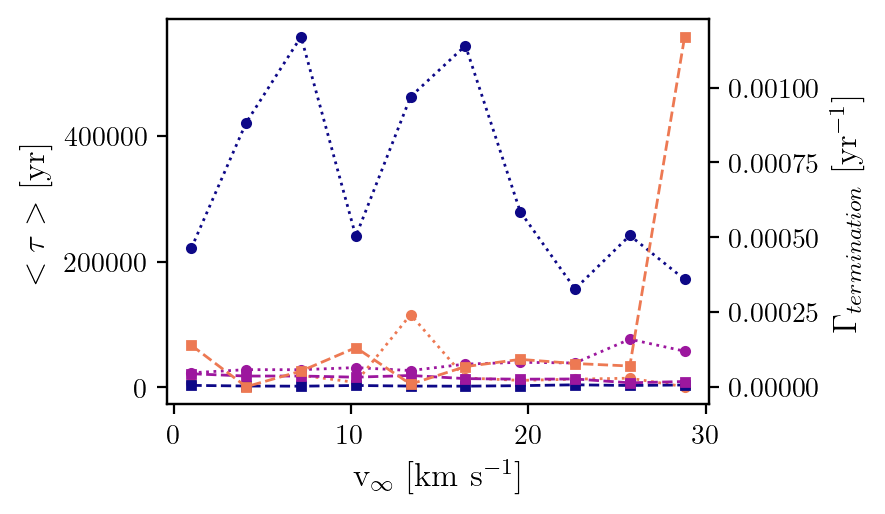

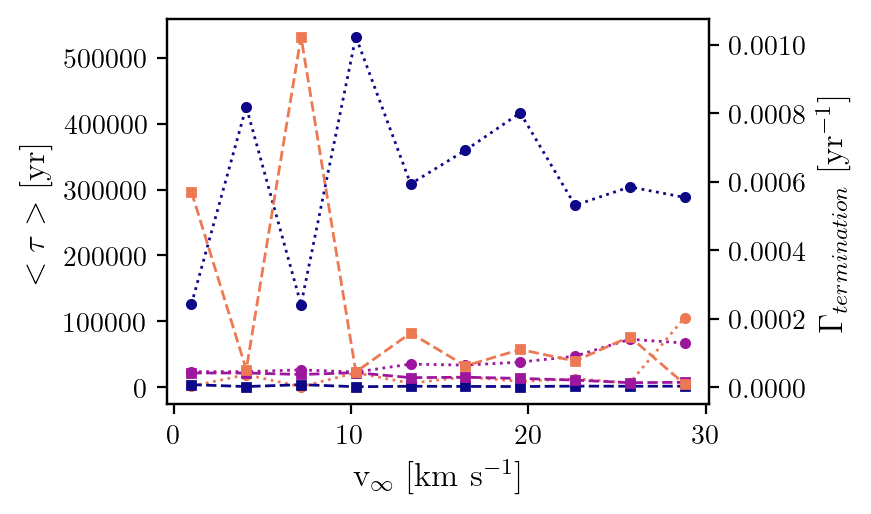

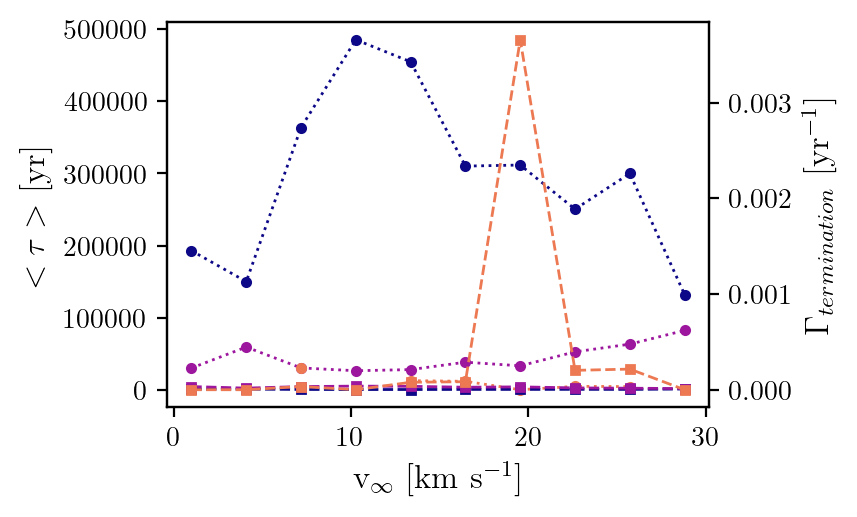

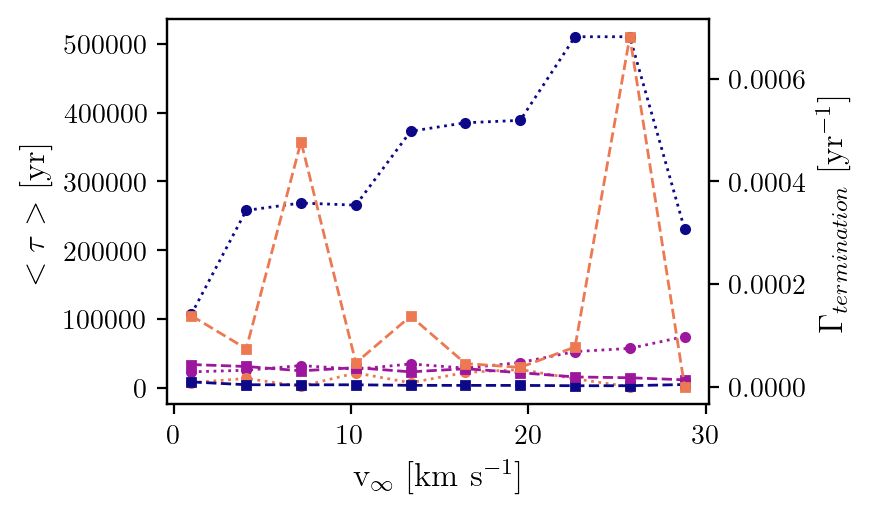

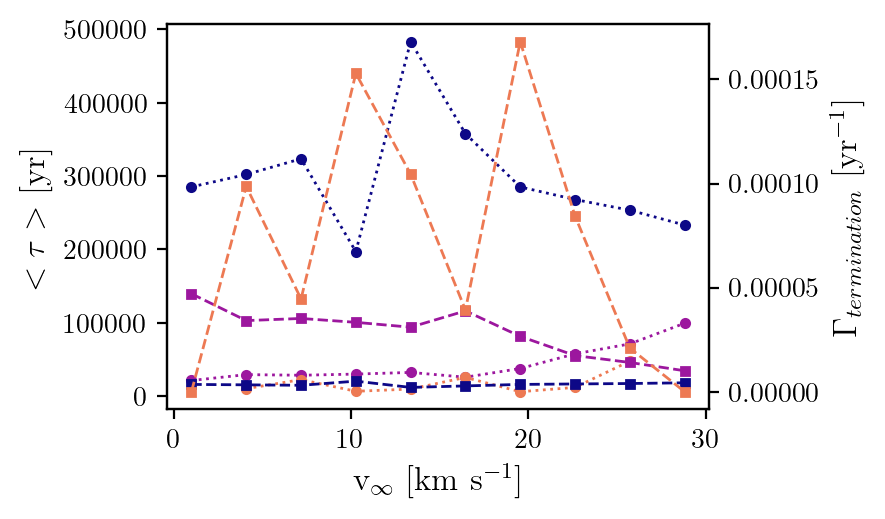

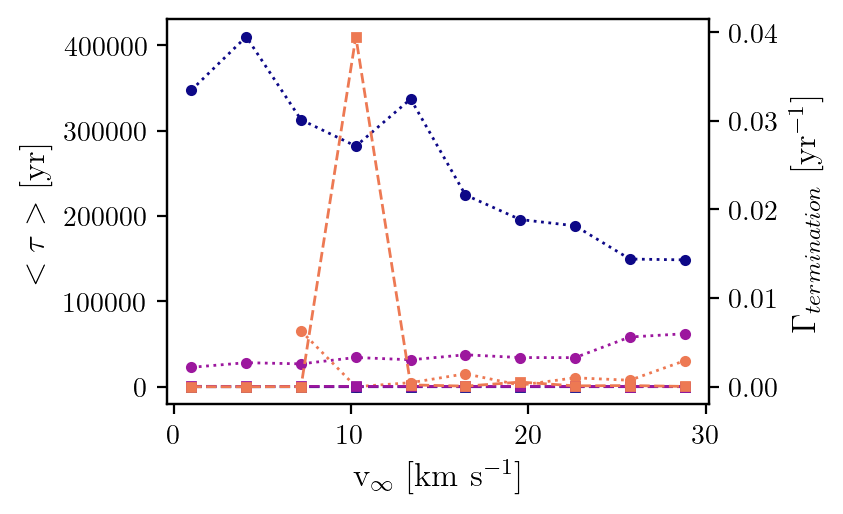

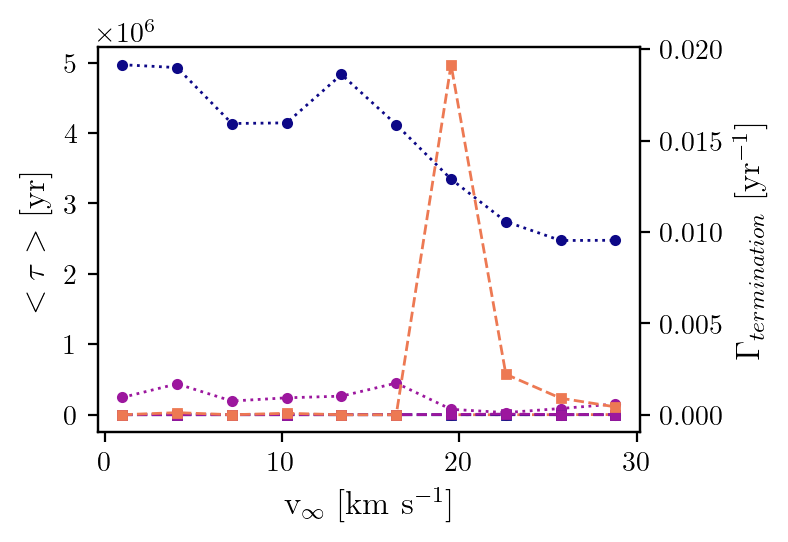

In [40]:
for run in runs_dict.keys():
    analysis = runs_dict[run]['analysis']
    name = analysis.name
    plotobj = pl.Plots(name=name, analysis=[analysis])
    mlist1 = ['total_rate','ejection_rate','collision_rate']
    mlabels1 = ['Total', 'Ejected', 'Collided']
    mylabel1 =r'$\Gamma_{termination}$ [yr$^{-1}$]'
    mlist3 = ['average_lifetime_total','average_lifetime_ejected','average_lifetime_collided']
    mlabels3 = ['Total', 'Ejected', 'Collided']
    mylabel3 =r'$<\tau>$ [yr]'
    mlists = [mlist3, mlist1]
    mlabels = [mlabels3, mlabels1]
    mylabels = [mylabel3, mylabel1]
    plotobj.plot_metric_wrt_v_twinaxis(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=None, analysis_name=name, save=False)

In [10]:
analysis_list = []
analysis_dicts = {}
for run in runs_dict.keys():
    analysis = runs_dict[run]['analysis']
    # name = analysis.get_name()
    analysis_list.append(analysis)
    # analysis_dicts[name] = catalog

In [11]:
plotobj2 = pl.Plots(name="BetaPictoris", analysis=analysis_list, exclude_zero_capture=True)
metric_list = ['n_captured', 'completed_count', 'collision_count_rebound', 'escape_C_count', 'time_exceeded_count']
metric_labels = ['Captured', 'Completed', 'Collided', 'Ejected', 'Time Exceeded']
mylabel = 'Number of Systems'
plotobj2.multiple_analysis_metric_wrt_v(metric_list=metric_list, metric_ylabel=mylabel, metric_labels=metric_labels, analysis_key= 'All', v_key='All', save=True)

Using cached results dictionary.
Using cached results dictionary.
Using cached results dictionary.
Using cached results dictionary.
Using cached results dictionary.
Using cached results dictionary.
Using cached results dictionary.
Using cached results dictionary.


AttributeError: 'float' object has no attribute 'get'

In [12]:
mylabel = 'Occurrence'
plotobj2.multiple_analysis_metric_wrt_v_multipanel(metric_list=metric_list, metric_ylabel=mylabel, metric_labels=metric_labels, analysis_key= 'All', v_key='All', normalize='n_sampled', save=True)

ValueError: Number of rows must be a positive integer, not 0

<Figure size 700x0 with 0 Axes>

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh_neq_n" in analysis_dict
✓ Found list metric "total_pbh

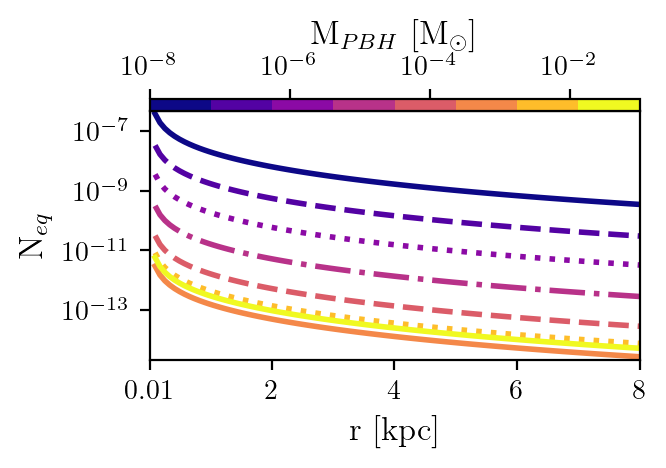

In [20]:
%matplotlib inline
flist = [1e0]
mlist0 = [['total_pbh_neq_n', 'Neq_pbh_f_{:.2e}'.format(f)] for f in flist]
mlabels0 = ['f={:.2f}'.format(f) for f in flist]
mylabel0 =r'N$_{eq}$'
mlist1 = [['total_pbh_neq_n','number_density_in_range_kpc3']]
# mlabels1 = ['$d$N$_{eq}$/$d$v$_\infty$']
# mylabel1 =r'$d$N$_{eq}$/$d$v$_\infty$ [n$_\infty$ AU$^{2}$]'
mlabels1 = [r'$n_{local}$']
mylabel1 =r'$n_{local}$ [M$_{\odot}$ kpc$^{-3}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
metricx = ['total_pbh_neq_n', 'range_kpc3']
metricxlabel = r'r [kpc]'
save_as = 'neq_vs_local_density_f1e0.png'
ticks = [[0.01, 2, 4, 6, 8], None, None]
plotobj2.multiple_analysis_metric_wrt_x(metric_list=mlist0, metric_ylabel=mylabel0, metric_xname=metricx, metric_x_label=metricxlabel, ticks=ticks, metric_labels=mlabels0, scale=['linear', 'log', 'log'], analysis_key= 'All', v_key='All', global_ylim=True, match_colors='analysis', unit_change=[1, 1, 1], normalize=False, save=True, save_as=save_as, fig_size=(3.5,2))

<unknown>:487: SyntaxWarning: invalid escape sequence '\o'
<unknown>:762: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1944: SyntaxWarning: invalid escape sequence '\%'
<unknown>:2203: SyntaxWarning: invalid escape sequence '\%'
<unknown>:487: SyntaxWarning: invalid escape sequence '\o'
<unknown>:762: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1944: SyntaxWarning: invalid escape sequence '\%'
<unknown>:2203: SyntaxWarning: invalid escape sequence '\%'


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict

📊 Processing metric 1/2: semi_major_axes
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries


/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found 

{}

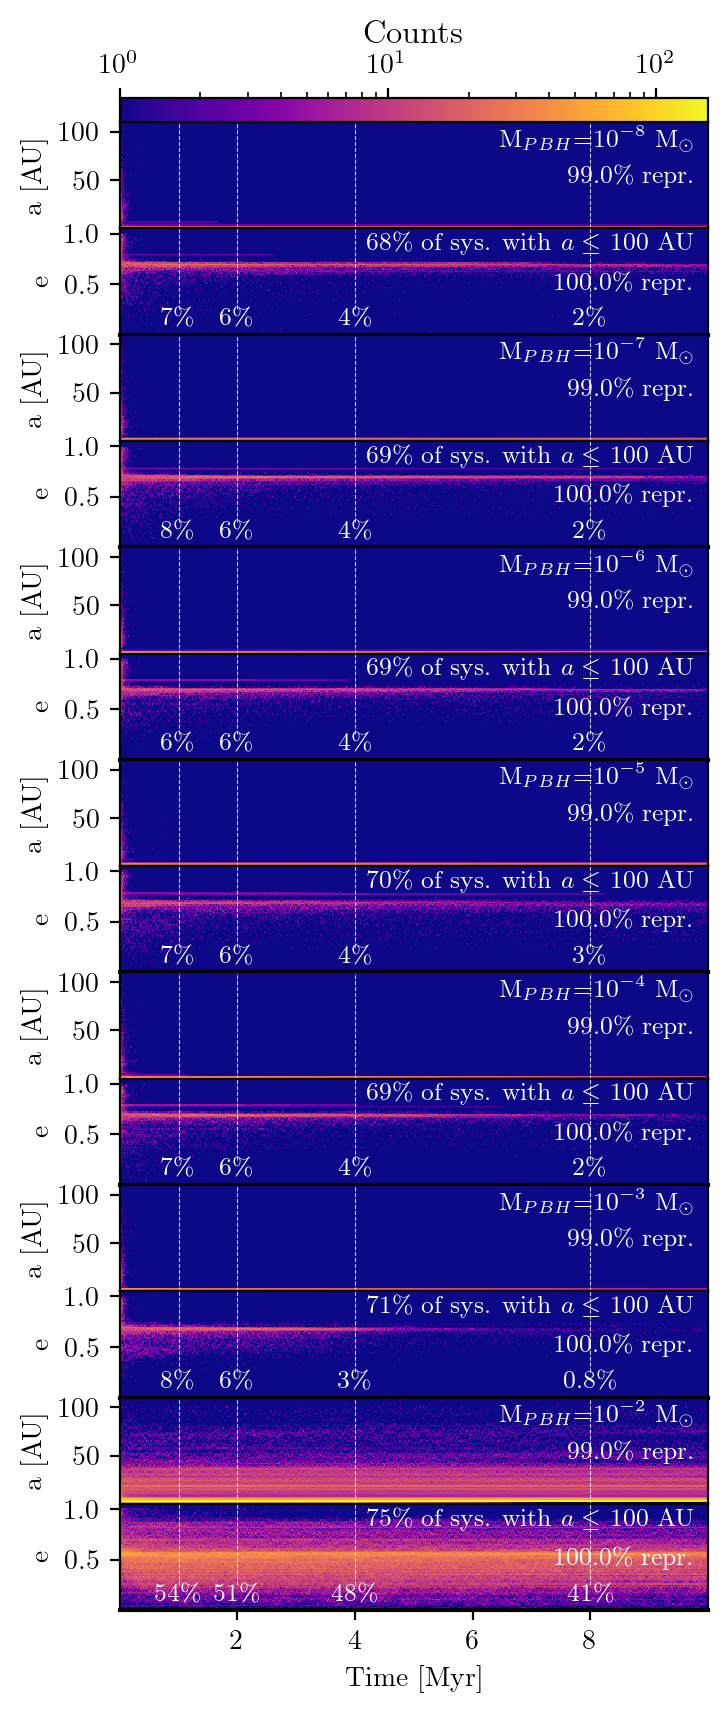

In [11]:
plotobj2.multiple_analysis_time_series_2dhistogram_multipanel_stacked(
    metric_names=['semi_major_axes', 'eccentricities'],
    metric_ylabels=[r'a [AU]', r'e'],
    time_ylabel=r'Time [Myr]',
    metric_ranges=[(0, 110), (0, 1.05)],
    ticks=[None, [50, 100], [0.5, 1.0], None],
    scale=['linear', 'linear', 'linear', 'log'],
    survivor_per_at_t = [1e6, 2e6, 4e6, 8e6],
    unit_change=[1e-6, 1, 1],
    dt_fixed=22,
    # analysis_key=[analysis_list[0].name, analysis_list[-1].name],

    metric_bins=75,
    mask_labels=[r'of sys. with $a \leq$ 100 AU', r'of sys. with $a \leq$ 100 AU', None],
    metric_masks=[{
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 100.0  # Average a over time
    },
        {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 100.0  # Average a over time
    }], # No mask for orbital_periods
    fig_size=(3.5, 8),  # Tall figure for 5 analyses × 2 metrics
    save_as='stacked_timeseries_histograms_dt22_bothmasked_100au.png'
)

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict

📊 Processing metric 1/2: semi_major_axes
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries


/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found 

{}

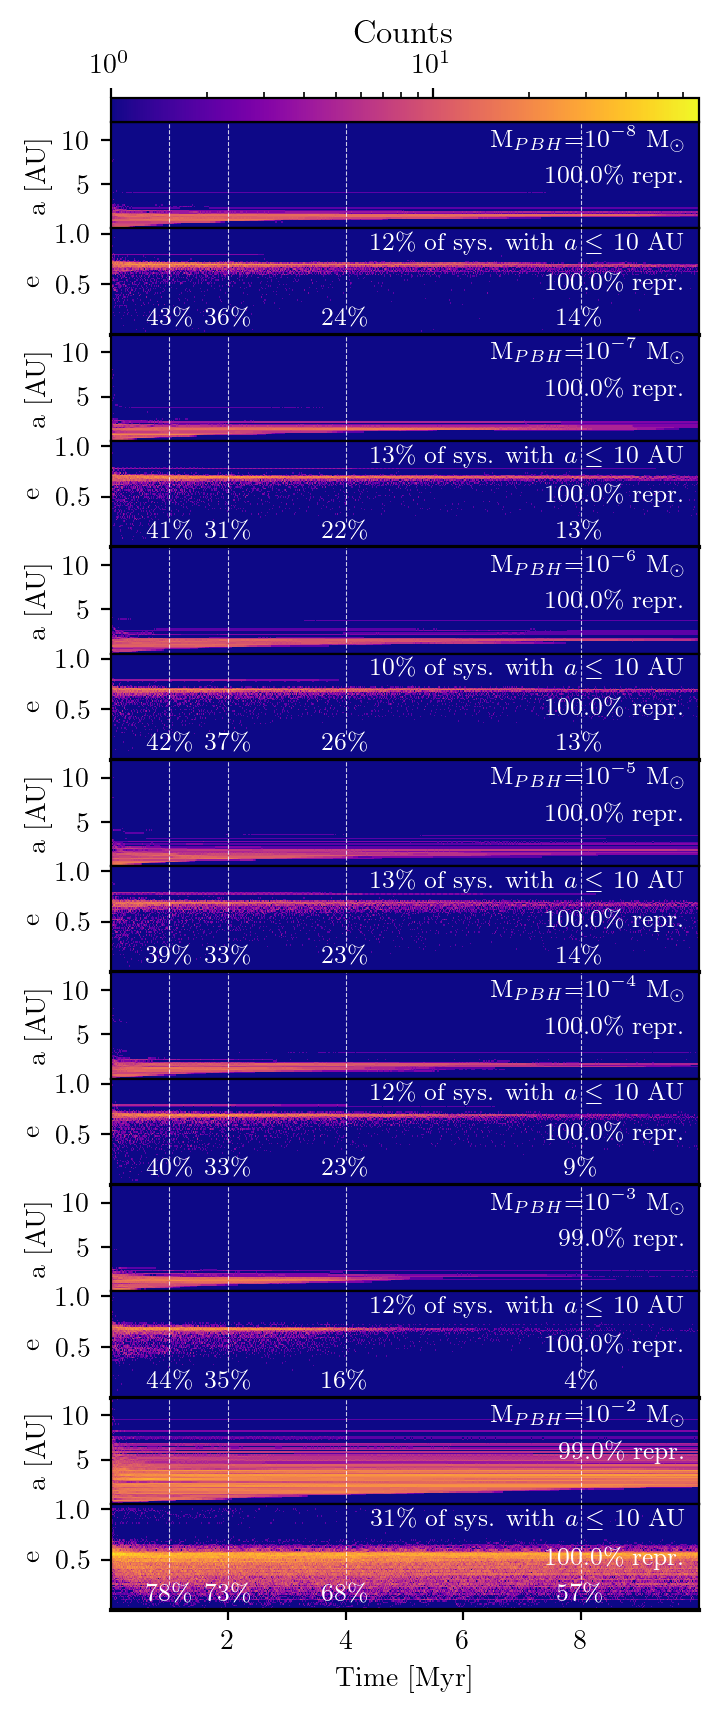

: 

In [ ]:
metric_mask=[None, {"type":"flag_contains", "substr" : "time_exceeded", "mask_type": "exclude"}] # ← Example: only include systems that exceeded time limit

plotobj2.multiple_analysis_time_series_2dhistogram_multipanel_stacked(
    metric_names=['semi_major_axes', 'eccentricities'],
    metric_ylabels=[r'a [AU]', r'e'],
    time_ylabel=r'Time [Myr]',
    metric_ranges=[(0, 12), (0, 1.05)],
    ticks=[None, [5, 10], [0.5, 1.0], None],
    scale=['linear', 'linear', 'linear', 'log'],
    survivor_per_at_t = [1e6, 2e6, 4e6, 8e6],
    unit_change=[1e-6, 1, 1],
    dt_fixed=22,
    metric_bins=75,
    mask_labels=[r'of sys. with $a \leq$ 10 AU', r'of sys. with $a \leq$ 10 AU', None],
    metric_masks=[{
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 10.0  # Average a over time
    },
        {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 10.0  # Average a over time
    }], # No mask for orbital_periods
    fig_size=(3.5, 8),  # Tall figure for 5 analyses × 2 metrics
    save_as='stacked_timeseries_histograms_dt22_bothmasked_10au.png'
)

In [92]:
print([analysis_list[-2].name, analysis_list[-1].name])

['BetaPictoris_s6_Mpbh1e-02_M4R4C3', 'BetaPictoris_s7_Mpbh1e-01_M4R4C3']


✓ Found in analysis_dict
✓ Found in analysis_dict

📊 Processing metric 1/2: semi_major_axes
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in r

{}

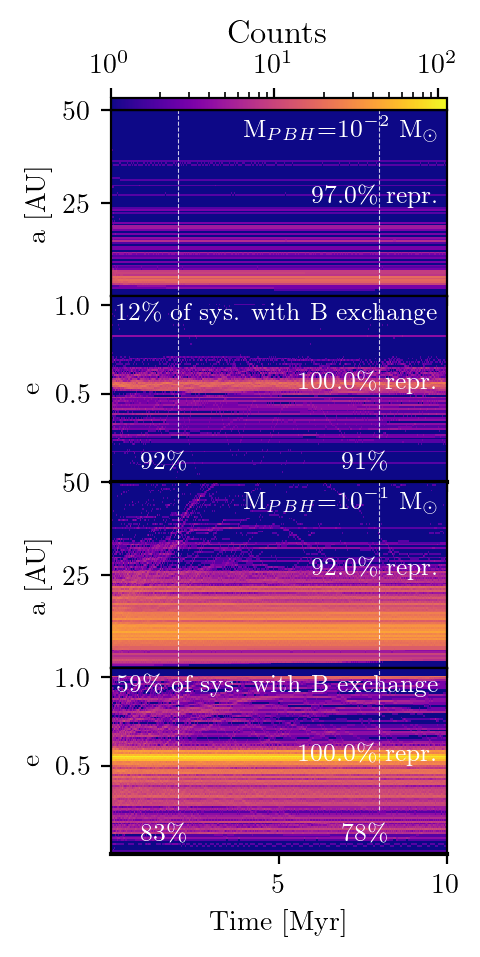

In [25]:
metric_mask=[{"type":"flag_contains", "substr" : "escape_B", "mask_type": "include"}, {"type":"flag_contains", "substr" : "escape_B", "mask_type": "include"}] # ← Example: only include systems that exceeded time limit

plotobj2.multiple_analysis_time_series_2dhistogram_multipanel_stacked(
    metric_names=['semi_major_axes', 'eccentricities'],
    metric_ylabels=[r'a [AU]', r'e'],
    time_ylabel=r'Time [Myr]',
    metric_ranges=[(0, 50), (0, 1.05)],
    ticks=[None, [25, 50], [0.5, 1.0], None],
    scale=['linear', 'linear', 'linear', 'log'],
    survivor_per_at_t = [2e6, 8e6],
    unit_change=[1e-6, 1, 1],
    dt_fixed=22,
    analysis_key=[analysis_list[-2].name, analysis_list[-1].name],
    metric_bins=100,
    mask_labels=[r'of sys. with B exchange', r'of sys. with B exchange', None],
    metric_masks= metric_mask,# No mask for orbital_periods
    fig_size=(2, 4),  # Tall figure for 5 analyses × 2 metrics
    save_as='stacked_timeseries_histograms_dt22_bothmasked_Bexchanges_include.png'
)

<unknown>:491: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1039: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1236: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1486: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2721: SyntaxWarning: invalid escape sequence '\%'
<unknown>:491: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1039: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1236: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1486: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2721: SyntaxWarning: invalid escape sequence '\%'


✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined mask sum: 65
✓ Found in an_entry
2 mask found, combined mask sum: 18
applying mask(s) for analysis BetaPictoris_s7_Mpbh1e-01_M4R4C3, v_key V1, metric semi_major_axis_time_avg sum: 18
Applied mask, 18 values after masking
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined mask sum: 65
✓ Found in an_entry
2 mask found, combined mask sum: 18
applying mask(s) for analysis BetaPictoris_s7_Mpbh1e-01_M4R4C3, v_key V1, metric orbital_period_time_avg sum: 18
Applied mask, 18 values after masking
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined mask sum: 53
✓ Found in an_entry
2 mask found, combined mask sum: 20
applying mask(s) for analysis BetaPictoris_s7_Mpbh1e-01_M4R4C3, v_key V4, metric semi_major_axis_time_avg sum: 20
Applied mask, 20 values after masking
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined mask sum: 53


/data/a.saricaoglu/repo/captus/src/plotting/Plotting_v2.py:215: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  metric_label = None


✓ Saved: betapic_semi_major_axis_histogram_masked_30au_noexchange.png


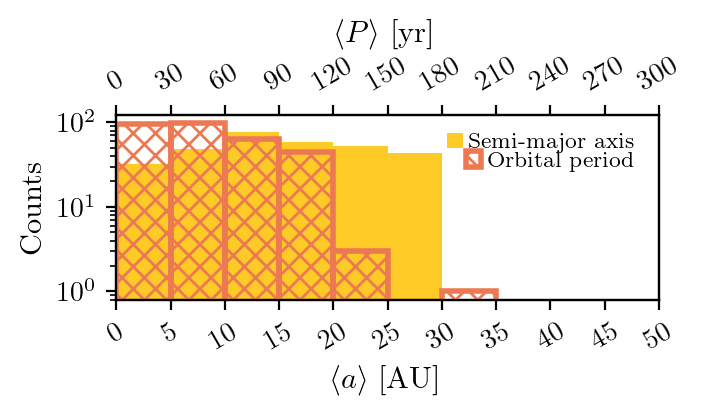

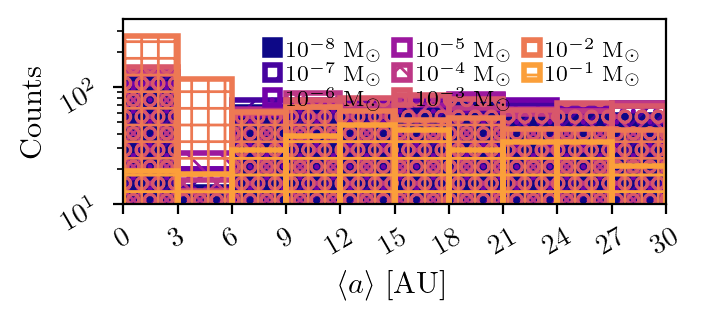

In [83]:
# metric_masks = [[{
#         "type": "where",
#         "key": "semi_major_axis_time_avg",  # Time series of semi-major axes
#         "entry_type": "CatalogEntry",
#         "predicate": lambda a_arr: [a for a in a_arr if a < 55]   # Average a over time
#     }],        ['Same']]
a_lim = 30
P_lim = None
# metric_masks = [[{
#         "key": "semi_major_axis_time_avg",  # Time series of semi-major axes
#         "predicate": lambda a: a < 50  # Average a over time
#     }],        ['Same']]
metric_masks = [[{
        "key": "termination_flag",
        "predicate": lambda a: "escape_B" not in a
    },{
        "key": "semi_major_axis_time_avg",
        "predicate": lambda a: a > 0 and a < a_lim  # Add a > 0
    },
    # {
    #     "key": "orbital_period_time_avg",
    #     "predicate": lambda a: a > 0 and a < P_lim  # Add a > 0
    # } 
    ], [{
        "key": "termination_flag",
        "predicate": lambda a: "escape_B" not in a
    },{
        "key": "semi_major_axis_time_avg",
        "predicate": lambda a: a > 0 and a < a_lim  # Add a > 0
    },
    # {
    #     "key": "orbital_period_time_avg",
    #     "predicate": lambda a: a > 0 and a < P_lim  # Add a > 0
    # } 
    ]]
k = 7
plotobj2.multiple_analysis_metric_array_wrt_twinxaxis_stephist(
    metric_lists=[['semi_major_axis_time_avg'], ['orbital_period_time_avg']],
    metric_xlabels=[r'$\langle a \rangle$ [AU]', r'$\langle P \rangle$ [yr]'],
    metric_range=[(None, 50), (None, 300)],
    bins=[11, 11],
    metric_masks=metric_masks,
    normalization = 2000,
    bin_scale=['log', 'log'],
    unit_change=[1,1,1],
    metric_scale=['linear', 'linear'],
    labels=[['Semi-major axis'], ['Orbital period']],
    analysis_key=[analysis_list[k].name],
    fig_size=(3.5, 1.2), save_as=f'betapic_semi_major_axis_and_period_k{k}_histogram_masked_{a_lim}au_noexchange.png'
    )
plotobj2.multiple_analysis_metric_array_wrt_twinxaxis_stephist(
    metric_lists=[['semi_major_axis_time_avg'], None],
    metric_xlabels=[r'$\langle a \rangle$ [AU]', None],
    metric_range=[None, None],
    bins=[11],
    metric_masks=metric_masks,
    normalization = 2000,
    bin_scale=['log', None],
    metric_scale=['linear', None],
    ticks=[None, [10, 100]],
    # labels=[['Semi-major Axes'], None],
    # analysis_key=[analysis_list[-2].name, analysis_list[-3].name, analysis_list[-4].name],
    fig_size=(3.5, 1.2), save_as=f'betapic_semi_major_axis_histogram_masked_{a_lim}au_noexchange.png'
    )

In [84]:
print(np.mean([0.344, 0.3545, 0.3565, 0.361, 0.356, 0.374]))

0.35766666666666663


<unknown>:491: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1039: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1236: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1486: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2721: SyntaxWarning: invalid escape sequence '\%'
<unknown>:491: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1039: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1236: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1486: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2721: SyntaxWarning: invalid escape sequence '\%'


✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined mask sum: 135
✓ Found in an_entry
2 mask found, combined mask sum: 109
applying mask(s) for analysis BetaPictoris_s7_Mpbh1e-01_M4R4C3, v_key V1, metric semi_major_axis_time_avg sum: 109
Applied mask, 109 values after masking
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined mask sum: 135
✓ Found in an_entry
2 mask found, combined mask sum: 109
applying mask(s) for analysis BetaPictoris_s7_Mpbh1e-01_M4R4C3, v_key V1, metric orbital_period_time_avg sum: 109
Applied mask, 109 values after masking
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined mask sum: 147
✓ Found in an_entry
2 mask found, combined mask sum: 112
applying mask(s) for analysis BetaPictoris_s7_Mpbh1e-01_M4R4C3, v_key V4, metric semi_major_axis_time_avg sum: 112
Applied mask, 112 values after masking
✓ Found in an_entry
✓ Found in rebound: 200 entries
1 mask found, combined m

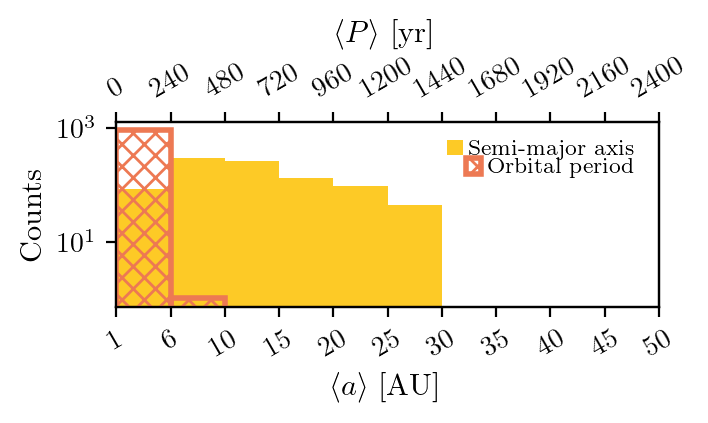

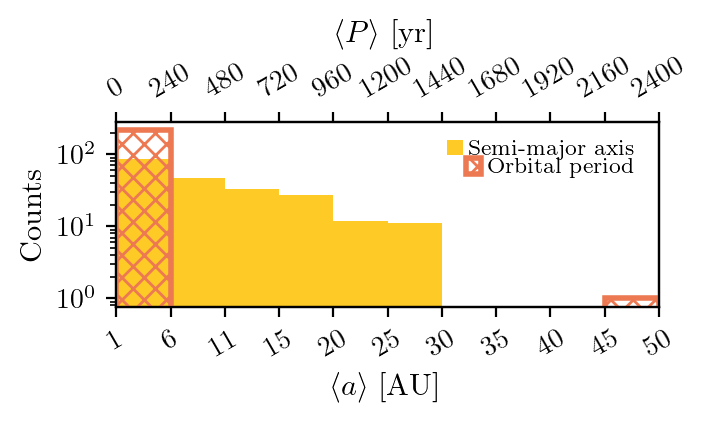

In [73]:
# metric_masks = [[{
#         "type": "where",
#         "key": "semi_major_axis_time_avg",  # Time series of semi-major axes
#         "entry_type": "CatalogEntry",
#         "predicate": lambda a_arr: [a for a in a_arr if a < 55]   # Average a over time
#     }],        ['Same']]
a_lim = 30
P_lim = None
# metric_masks = [[{
#         "key": "semi_major_axis_time_avg",  # Time series of semi-major axes
#         "predicate": lambda a: a < 50  # Average a over time
#     }],        ['Same']]
metric_masks = [[{
        "key": "termination_flag",
        "predicate": lambda a: "escape_B" in a
    },{
        "key": "semi_major_axis_time_avg",
        "predicate": lambda a: a > 0.3 and a < a_lim  # Add a > 0
    },
    # {
    #     "key": "orbital_period_time_avg",
    #     "predicate": lambda a: a > 0 and a < P_lim  # Add a > 0
    # } 
    ], [{
        "key": "termination_flag",
        "predicate": lambda a: "escape_B"  in a
    },{
        "key": "semi_major_axis_time_avg",
        "predicate": lambda a: a > 0.3 and a < a_lim  # Add a > 0
    },
    # {
    #     "key": "orbital_period_time_avg",
    #     "predicate": lambda a: a > 0 and a < P_lim  # Add a > 0
    # } 
    ]]
k = 7
plotobj2.multiple_analysis_metric_array_wrt_twinxaxis_stephist(
    metric_lists=[['semi_major_axis_time_avg'], ['orbital_period_time_avg']],
    metric_xlabels=[r'$\langle a \rangle$ [AU]', r'$\langle P \rangle$ [yr]'],
    metric_range=[(None, 50), (None, 2400)],
    bins=[11, 11],
    metric_masks=metric_masks,
    normalization = 2000,
    bin_scale=['log', 'log'],
    unit_change=[1,1,1],
    metric_scale=['linear', 'linear'],
    labels=[['Semi-major axis'], ['Orbital period']],
    analysis_key=[analysis_list[k].name],
    fig_size=(3.5, 1.2), save_as=f'betapic_semi_major_axis_and_period_k{k}_histogram_masked_{a_lim}au_exchangeonly.png'
    )
k = 6
plotobj2.multiple_analysis_metric_array_wrt_twinxaxis_stephist(
    metric_lists=[['semi_major_axis_time_avg'], ['orbital_period_time_avg']],
    metric_xlabels=[r'$\langle a \rangle$ [AU]', r'$\langle P \rangle$ [yr]'],
    metric_range=[(None, 50), (None,2400)],
    bins=[11, 11],
    metric_masks=metric_masks,
    normalization = 2000,
    bin_scale=['log', 'log'],
    unit_change=[1,1,1],
    metric_scale=['linear', 'linear'],
    labels=[['Semi-major axis'], ['Orbital period']],
    analysis_key=[analysis_list[k].name],
    fig_size=(3.5, 1.2), save_as=f'betapic_semi_major_axis_and_period_k{k}_histogram_masked_{a_lim}au_exchangeonly.png'
)

### Capture crossection & term. rate wrt. v_inf

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
Formatting 1.99e+22 as 1.99 × 10^22
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Fou

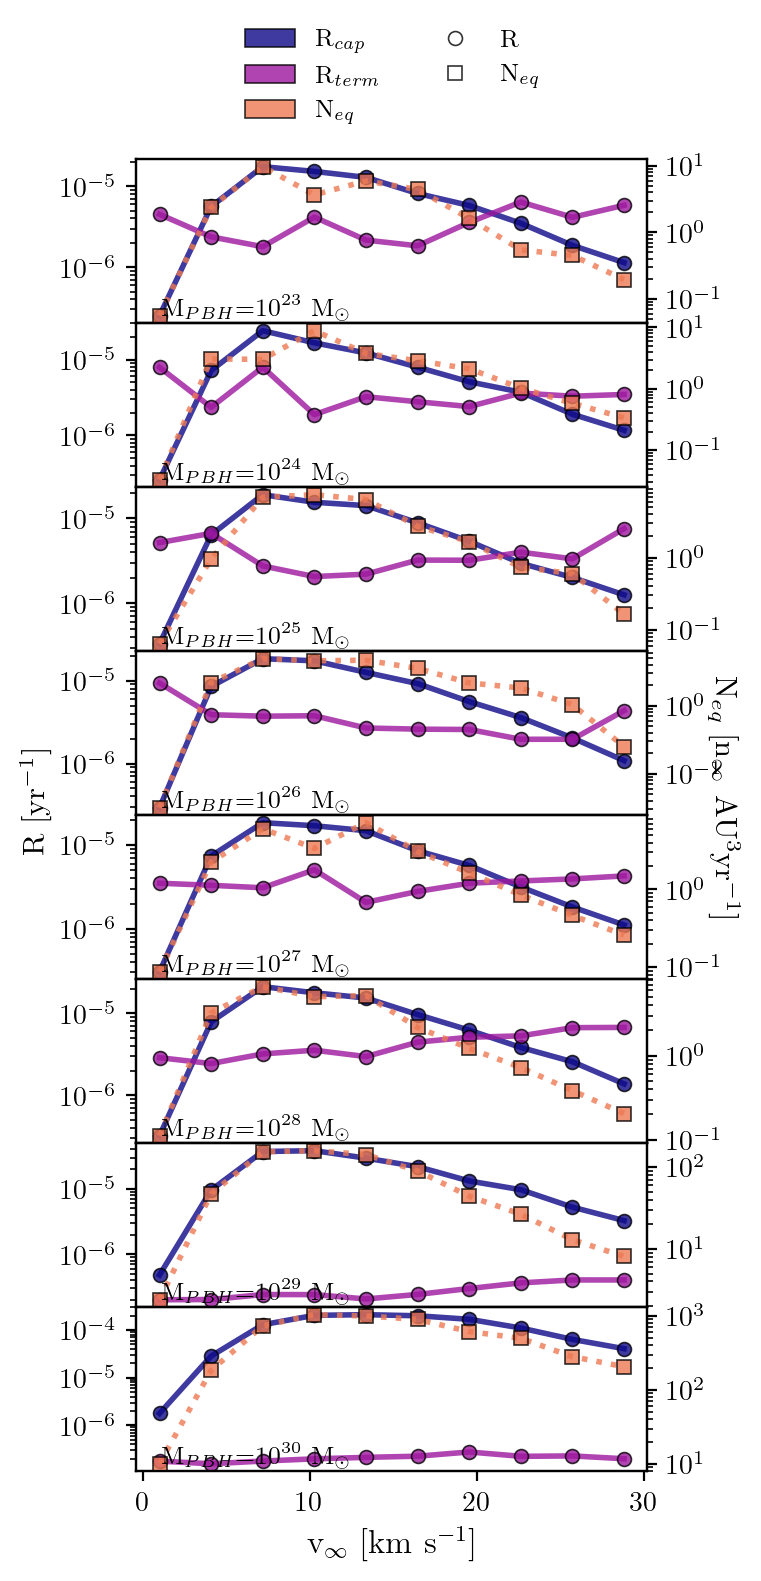

In [11]:
mlist0 = ['capture_rate', 'total_rate']
mlabels0 = ['R$_{cap}$', 'R$_{term}$']
mylabel0 =r'R [yr$^{-1}$]'
mlist1 = ['total_systems_neq']
mlabels1 = ['N$_{eq}$']
mylabel1 =r'N$_{eq}$ [n$_\infty$ AU$^{3}$yr$^{-1}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
plotobj2.multiple_analysis_metric_wrt_v_twinaxis_multipanel(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=mlabels, scale=['linear', 'log', 'log'], analysis_key= 'All', v_key='All', global_ylim=False, match_colors=False, unit_change=[1e-3, 1, 1], normalize=False, save=True)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3778917/1643658663.py:2: SyntaxWarning: invalid escape sequence '\s'
  mlabels0 = [ '$\sigma_{cap}$']


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurre

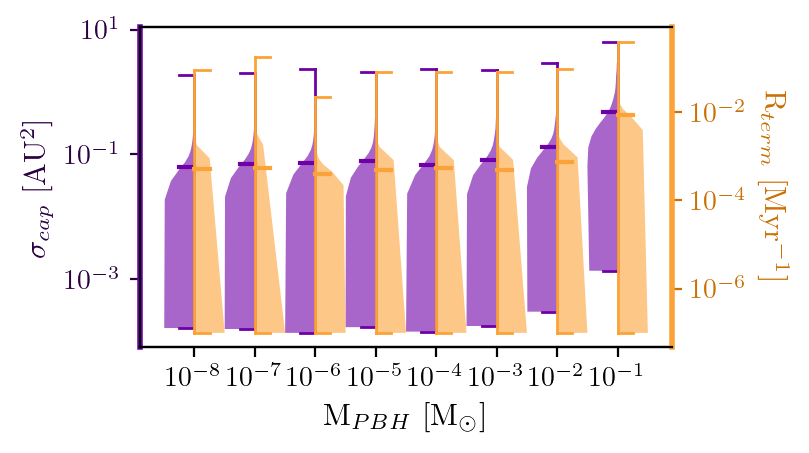

In [11]:
mlist0 = ['dsigma_au2']
mlabels0 = [ '$\sigma_{cap}$']
mylabel0 =r'$\sigma_{cap}$ [AU$^{2}$]'
mlist1 = ['terminations']
# mlabels1 = ['$d$N$_{eq}$/$d$v$_\infty$']
# mylabel1 =r'$d$N$_{eq}$/$d$v$_\infty$ [n$_\infty$ AU$^{2}$]'
mlabels1 = [r'R$_{term}$']
mylabel1 =r'R$_{term}$ [Myr$^{-1}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
plotobj2.multiple_analysis_metric_array_wrt_m_twinaxis_violin(
    metric_lists=mlists, 
    metric_labels=mlabels,
    metric_ylabels=mylabels,
    fig_size=(3.5, 2),
    save=True,
    scale=['log', 'log', 'log'] ,#[metric1[x,y,z], metric2[x,y,z]]
    unit_change= [1/const.M_sun.value, 1, 1] #[metric1[x,y,z], metric2[x,y,z]]
    # metric_masks=[[None], [{"type":"flag_contains", "substr" : "time_exceeded", "mask_type": "exclude"}]]
    )

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3778917/3727804615.py:2: SyntaxWarning: invalid escape sequence '\s'
  mlabels0 = [ '$\sigma_{cap}$']


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
Formatting 1.00e-08 as 1.00 × 10^-8
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurr

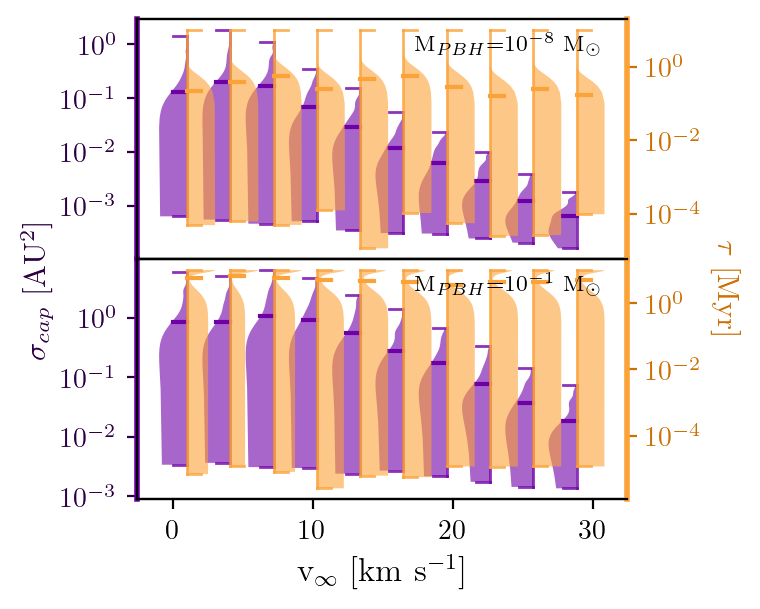

In [12]:
mlist0 = ['dsigma_au2']
mlabels0 = [ '$\sigma_{cap}$']
mylabel0 =r'$\sigma_{cap}$ [AU$^{2}$]'
mlist1 = ['lifetimes_array']
# mlabels1 = ['$d$N$_{eq}$/$d$v$_\infty$']
# mylabel1 =r'$d$N$_{eq}$/$d$v$_\infty$ [n$_\infty$ AU$^{2}$]'
mlabels1 = [r'$\tau$ [Myr]']
mylabel1 =r'$\tau$ [Myr]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]

plotobj2.multiple_analysis_metric_array_wrt_v_twinaxis_multipanel(
    metric_lists=mlists,
    metric_ylabels= (mylabel0, mylabel1),
    scale=['log','log'],
    analysis_key=[analysis_list[0].name, analysis_list[-1].name],
    v_key='All',
    global_ylim=False,
    unit_change=[1, 1e-6],
    fig_size=(3.5,3),
    save=True,
    save_as='capture_cross_section_vs_lifetime_first_last.png'
)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3778917/386081291.py:2: SyntaxWarning: invalid escape sequence '\s'
  mlabels0 = [ '$\sigma_{cap}$']


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurre

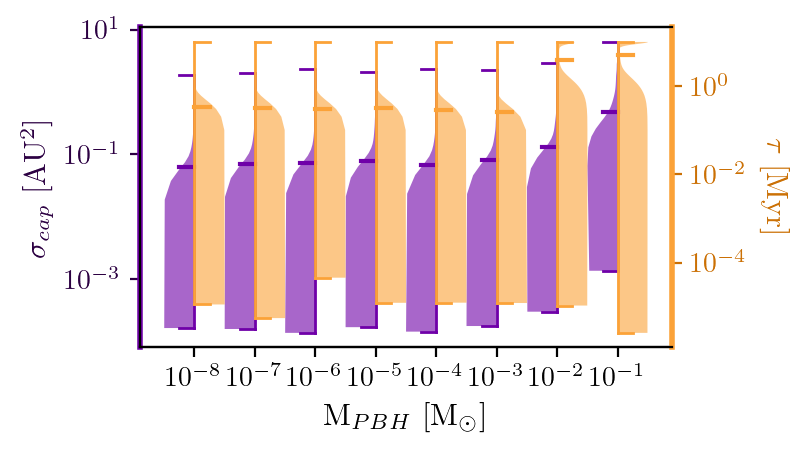

In [13]:
mlist0 = ['dsigma_au2']
mlabels0 = [ '$\sigma_{cap}$']
mylabel0 =r'$\sigma_{cap}$ [AU$^{2}$]'
mlist1 = ['lifetimes_array']
# mlabels1 = ['$d$N$_{eq}$/$d$v$_\infty$']
# mylabel1 =r'$d$N$_{eq}$/$d$v$_\infty$ [n$_\infty$ AU$^{2}$]'
mlabels1 = [r'$\tau$ [Myr]']
mylabel1 =r'$\tau$ [Myr]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
plotobj2.multiple_analysis_metric_array_wrt_m_twinaxis_violin(
    metric_lists=mlists, 
    metric_labels=mlabels,
    metric_ylabels=mylabels,
    fig_size=(3.5, 2),
    save=True,
    scale=['log', 'log', 'log'] ,#[metric1[x,y,z], metric2[x,y,z]]
    unit_change= [1/const.M_sun.value, 1, 1e-6], #[metric1[x,y,z], metric2[x,y,z]]
    # metric_masks=[[None], [{"type":"flag_contains", "substr" : "time_exceeded", "mask_type": "exclude"}]]
    save_as='capture_cross_section_vs_lifetime_combined.png'
    )

In [ ]:
%matplotlib inline
flist = [1e0]
mlist0 = [['total_pbh_neq_n', 'Neq_pbh_f_{:.2e}'.format(f)] for f in flist]
mlabels0 = ['f={:.2f}'.format(f) for f in flist]
mylabel0 =r'N$_{eq}$'
mlist1 = [['total_pbh_neq_n','number_density_in_range_kpc3']]
# mlabels1 = ['$d$N$_{eq}$/$d$v$_\infty$']
# mylabel1 =r'$d$N$_{eq}$/$d$v$_\infty$ [n$_\infty$ AU$^{2}$]'
mlabels1 = [r'$n_{local}$']
mylabel1 =r'$n_{local}$ [M$_{\odot}$ kpc$^{-3}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
metricx = ['total_pbh_neq_n', 'range_kpc3']
metricxlabel = r'r [kpc]'
save_as = 'neq_vs_local_density_f1e0.png'
ticks = [[0.01, 2, 4, 6, 8], None, None]
plotobj2.multiple_analysis_metric_wrt_x(metric_list=mlist0, metric_ylabel=mylabel0, metric_xname=metricx, metric_x_label=metricxlabel, ticks=ticks, metric_labels=mlabels0, scale=['linear', 'log', 'log'], analysis_key= 'All', v_key='All', global_ylim=True, match_colors='analysis', unit_change=[1, 1, 1], normalize=False, save=True, save_as=save_as, fig_size=(3.5,2))

✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  151 valid points
  Reversed axes: x reversed=True, y reversed=False
  0 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  171 valid points
  Reversed axes: x reversed=True, y reversed=False
  2 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  97 valid points
  Reversed axes: x reversed=True, y reversed=False
  0 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  77 valid points
  Reversed axes: x reversed=True, y reversed=False
  0 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  65 valid points
  Reversed axes: x reversed=True, y reversed=False
  0 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  56 valid points
  Reversed axes: x reversed=True, y

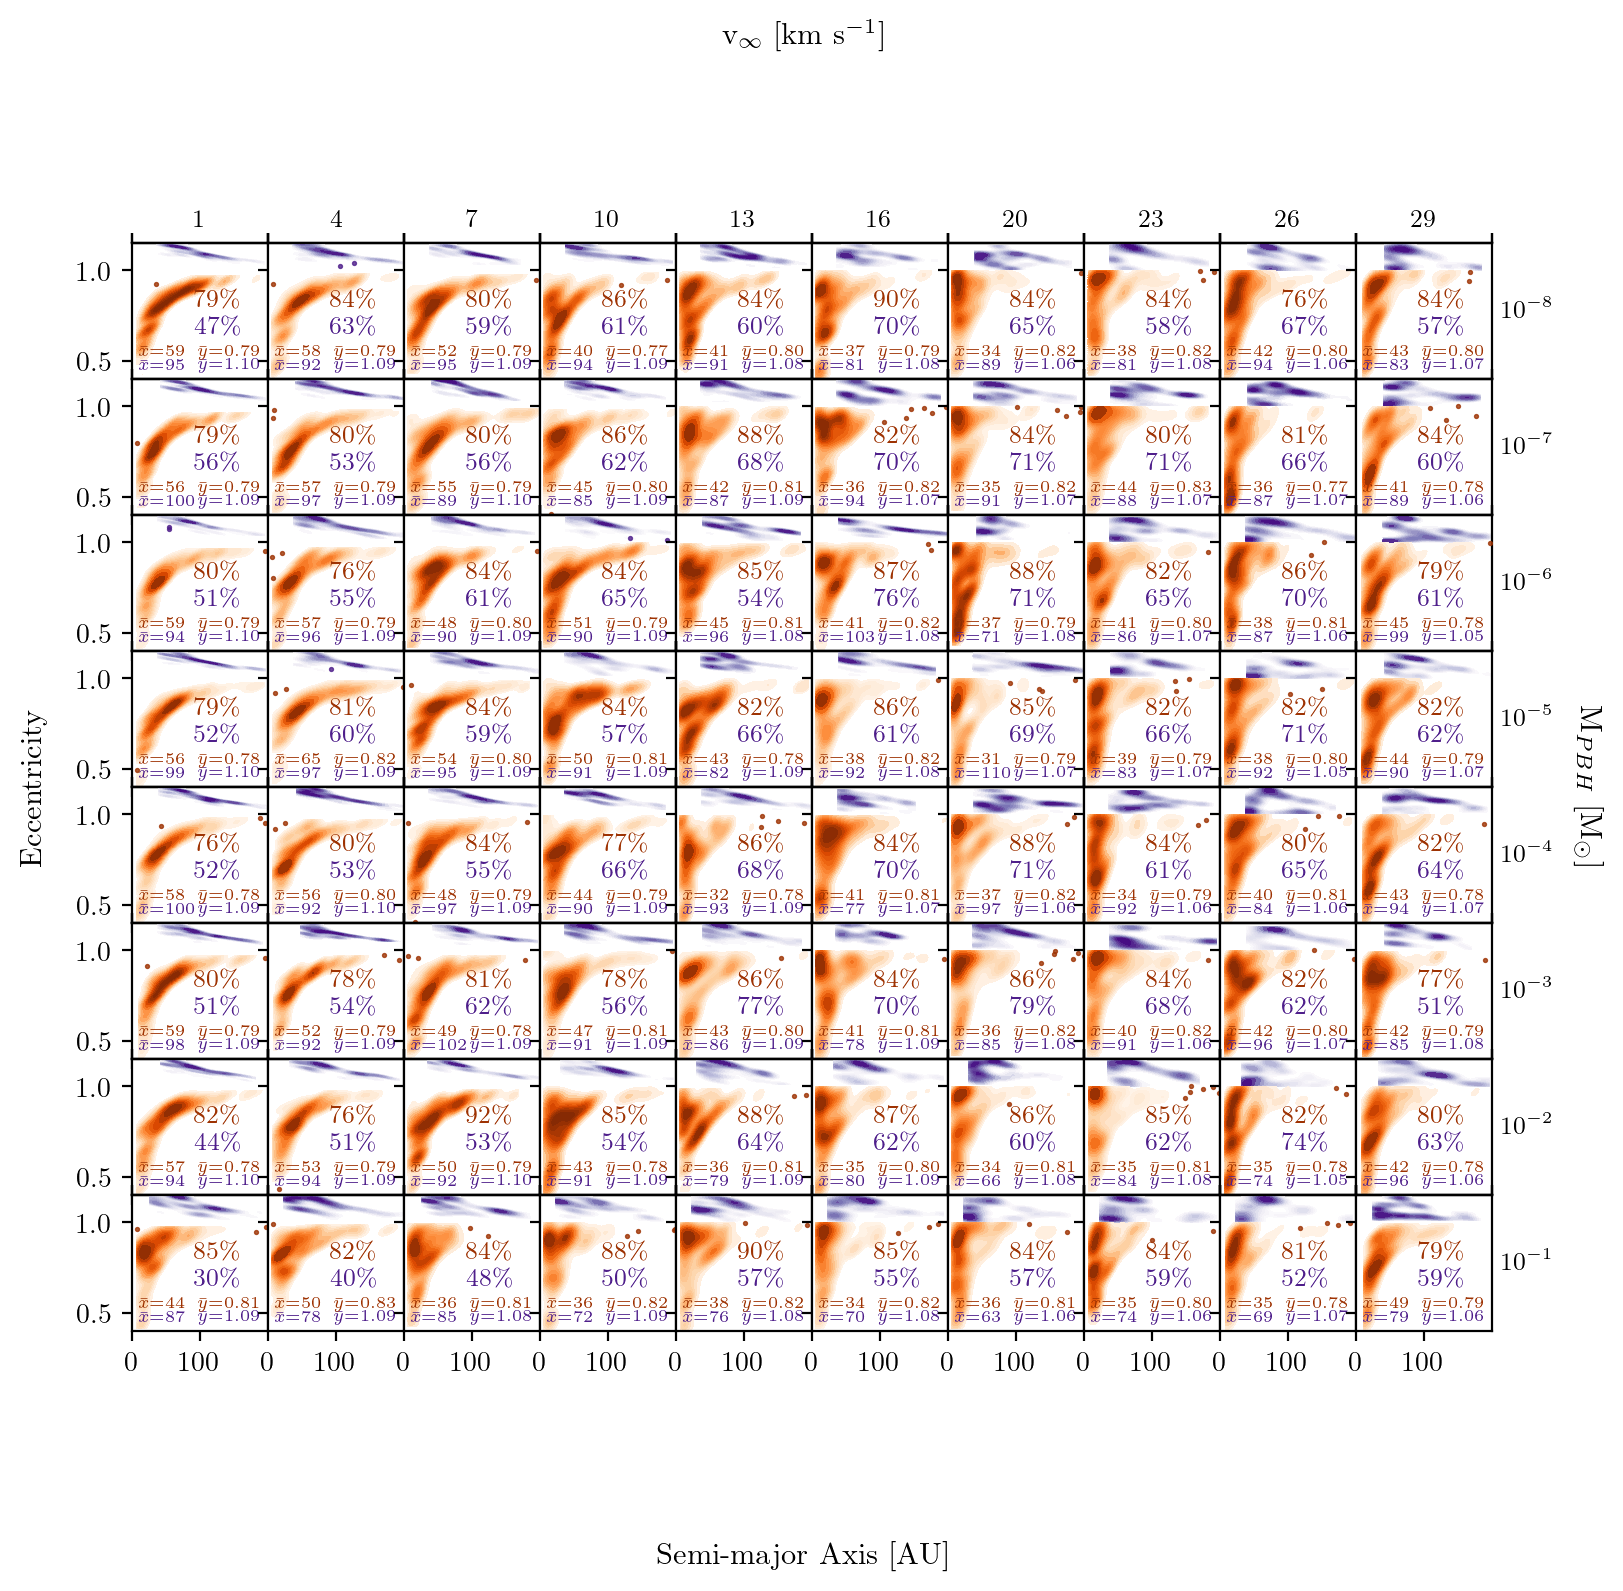

In [9]:
plotobj2.multiple_analysis_metric_gaussian_kde_multipanel(
    metric_xnames=['nocap_a_au', 'cap_a_au'],
    metric_ynames=['nocap_e', 'cap_e'],
    metric_xlabel='Semi-major Axis [AU]',
    metric_ylabel='Eccentricity',
    unit_change=[1, 1, 1],
    # analysis_key=[analysis_list[0].name, analysis_list[-1].name],
    cmaps=['Purples', 'Oranges'],
    scale=['linear', 'linear', 'linear'],
    bw_adjust=0.6,  # ← Bandwidth adjustment
    thresh=0.1,      # ← Outlier threshold (10% of max)
    plot_outliers=True,  # ← Show outliers
    ranges=[(0, 200), (0.4, 1.15), None],
    ticks=[(0, 100), (0.5,1.0), None],
    save=True,
    cut=0.0,
    mean_annotations=True,
    add_negative_top_axis=True,
    reverse_axes = [[True, False], [False, False]],  # ← Reverse x-axis for row 0
    percentage_annotations=True,
    fig_size=(8, 8),
    save_as="a_e_kde_initial.png",
    # metric_mask=[None, {"type":"flag_contains", "substr" : "time_exceeded", "mask_type": "exclude"}] # ← Example: only include systems that exceeded time limit

)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


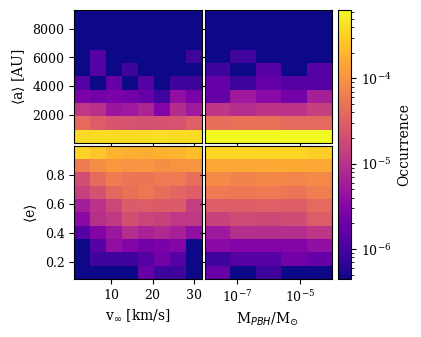

In [127]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'eccentricities'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$e$\rangle$'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[8, 5],
    metric_bins=10,
    annotate_bins=False,
    custom_voxel_bins=False,
    voxel_range=[[[1, 32], [0.9e-8, 1.1e-4]], [[1, 32], [0.9e-8, 1.1e-4]]],
    metric_range=None,  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    metric_masks=None,
    save=True,  # ← Don't save until we confirm it works
    save_as="a_e_averages_histogram.png",
    fig_size=(4, 3.5)
)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


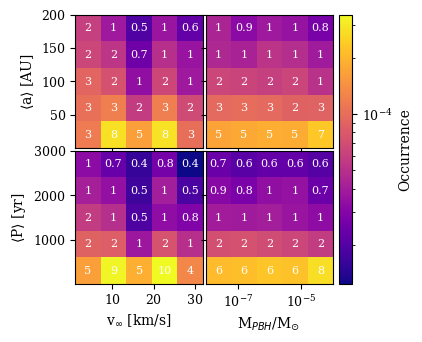

In [128]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'orbital_periods'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$P$\rangle$ [yr]'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[5, 5],
    metric_bins=5,
    custom_voxel_bins=False,
    voxel_range=[[[1, 32], [0.9e-8, 1.1e-4]], [[1, 32], [0.9e-8, 1.1e-4]]],
    metric_range=[[1e-6, 200], [1e-6, 3000]],  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    normalize_annotation='capture_count',
    annotate_bins=True,
    metric_masks=None,
    save=True,  # ← Don't save until we confirm it works
    fig_size=(4, 3.5)
)

Axis 0: Collected 16287 data points for 'orbital_periods'
Axis 1: Collected 16287 data points for 'orbital_periods'


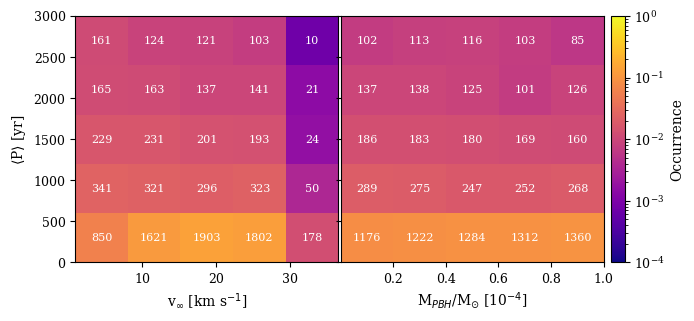

In [143]:
plotobj4.multiple_analysis_voxel_2dhistogram(
    metric_name='orbital_periods',        # ← Keyword arg
    metric_ylabel=r'$\langle$P$\rangle$ [yr]', # ← Keyword arg
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_{\infty}$ [km s$^{-1}$]', r'M$_{PBH}$/M$_{\odot}$ [10$^{-4}$]'],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=['linear', 'linear', 'log'],
    v_key='All',
    global_ylim=False,
    voxel_bins=5,
    metric_bins=5,
    voxel_range=None,
    metric_range=[0, 3000],
    unit_change=[[1e-3, 1, 1], [1e4, 1, 1]],
    v_lim=[1e-4, 1],
    normalize='sample_count',
    annotate_bins=True,
    save=True
)

In [ ]:
# Option 1: Skip problematic lines
exoplanet_df = pd.read_csv(
    '/grad/a.saricaoglu/Downloads/PS_2026.04.03_17.32.03.csv',
)

# Extract high eccentricity planets with no determined radius
print("Total planets in dataset:", len(exoplanet_df))
no_radius = exoplanet_df[exoplanet_df['pl_rade'].isnull()]
print(len(no_radius))
high_eccentricity = exoplanet_df[(exoplanet_df['pl_orbeccen'] > 0.5) & (exoplanet_df['pl_rade'].isnull())]
print(len(high_eccentricity))

Text(0.5, 1.0, 'Eccentricity vs Semi-major Axis')

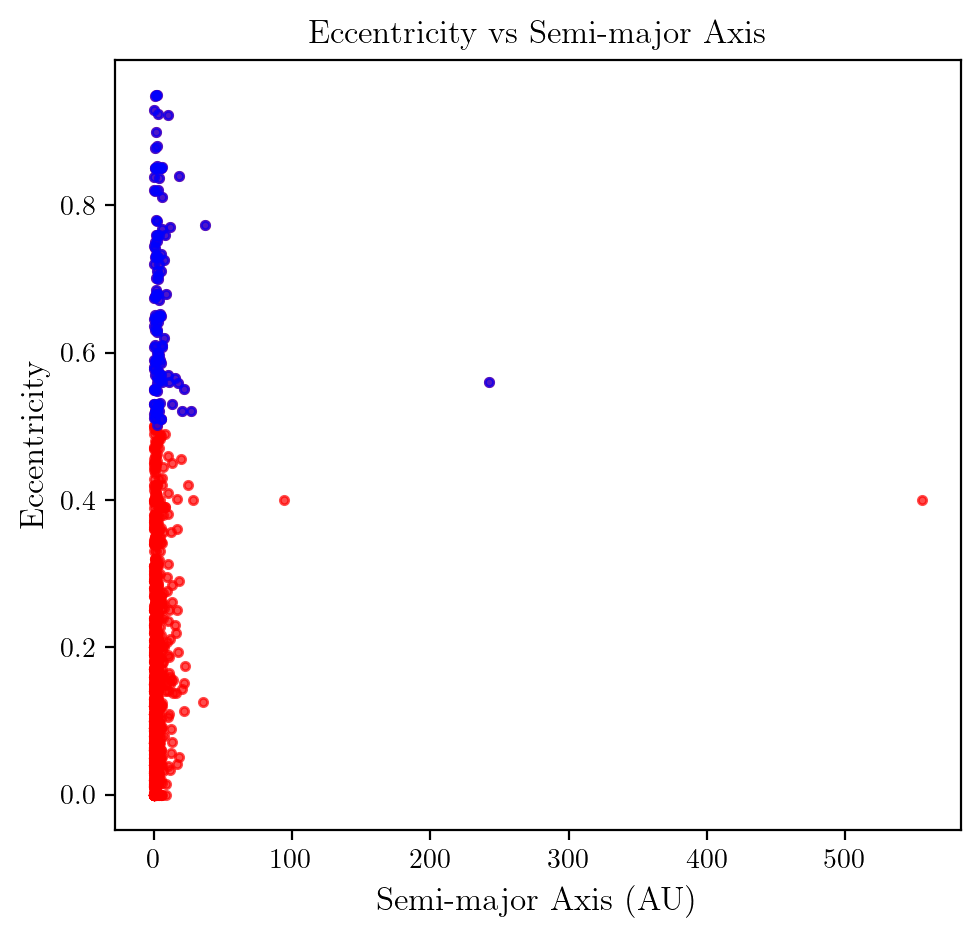

In [71]:
# Scatter plots to visualize the relationships
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(no_radius['pl_orbsmax'], no_radius['pl_orbeccen'], color='red', label='No Radius', alpha=0.7, marker='.')
plt.scatter(high_eccentricity['pl_orbsmax'], high_eccentricity['pl_orbeccen'], color='blue', label='High Eccentricity', alpha=0.7, marker='.')
plt.xlabel('Semi-major Axis (AU)')
plt.ylabel('Eccentricity')
plt.title('Eccentricity vs Semi-major Axis')

399


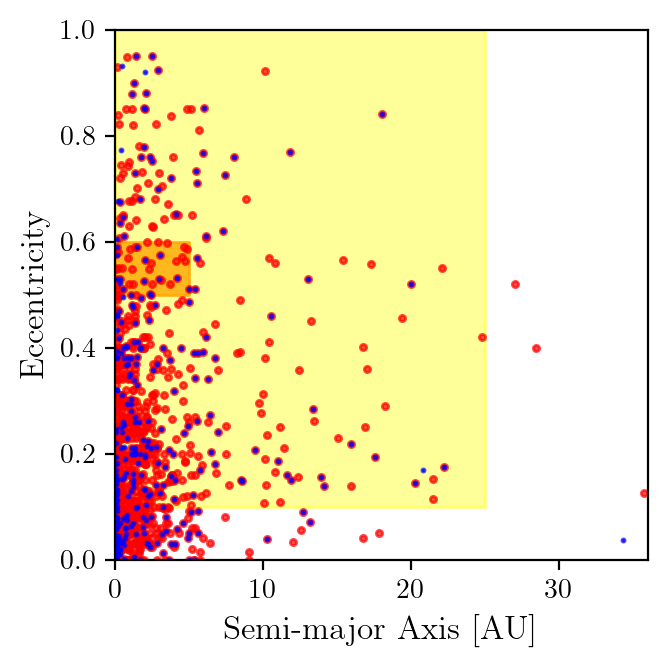

In [82]:
# Systems with stellar masses aroun 1.75 solar masses with planet masses around 1-100 jupiter masses seem to be the ones with high eccentricity and no radius measurements. This could be due to observational biases or intrinsic properties of those systems. Further investigation would be needed to understand the underlying reasons for this pattern.
sun_mass_stars = exoplanet_df[exoplanet_df['st_mass'].between(0.8, 1.2)]
jupiter_mass_planets = exoplanet_df[exoplanet_df['pl_bmassj'].between(1, 10)]
sun_mass_stars_with_jupiter_planets = sun_mass_stars[sun_mass_stars['pl_bmassj'].between(1, 10)]
print(len(sun_mass_stars_with_jupiter_planets))
plt.figure(figsize=(3.5, 3.5))
plt.fill_betweenx([0.1, 1], 0, 25, color='yellow', alpha=0.4, label='B-Exchange Region in SJ System ')
plt.fill_betweenx([0.5, 0.6], 0, 5, color='orange', alpha=0.8)


# plt.scatter(exoplanet_df['pl_orbsmax'], exoplanet_df['pl_orbeccen'], color='gray', label='RV Exoplanets', alpha=0.5, marker='o')
plt.scatter(no_radius['pl_orbsmax'], no_radius['pl_orbeccen'], color='red', label='Systems Unknown Radius', alpha=0.7, marker='o',s=5)
plt.scatter(sun_mass_stars_with_jupiter_planets['pl_orbsmax'], sun_mass_stars_with_jupiter_planets['pl_orbeccen'], color='blue', label='Sun-like Stars with Jovian Planets', alpha=0.7, marker='.', s=5)
plt.xlabel('Semi-major Axis [AU]')
plt.ylabel('Eccentricity')
plt.xlim(0, 36)
plt.ylim(0, 1)
# plt.legend()
plt.tight_layout()
plt.savefig('exoplanets_eccentricity_vs_semi_major_axis.png', dpi=300)
